
<a id="summary"></a>

## Notebook 3 — RFM Scoring, Clustering, and Segment Profiling

This notebook builds customer-level behavioral intelligence from completed transactions in order to answer roadmap **Q6–Q10**. It defines the RFM rules used in this project, engineers clustering-ready features, selects an operational k-means segmentation, and profiles each segment through product ownership and product activation behavior.

### Notebook flow

1. [Part 1 — RFM design & data loading](#part-1)
2. [Part 2 — RFM metrics and Feature Engineering](#part-2)
3. [Part 3 — clustering & segment profiles](#part-3)
4. [Part 4 — products & utilization](#part-4)

**Part 1 details**

1.1 [RFM ranking criteria (locked definitions)](#rfm-criteria)
1.2 [Load raw tables from Supabase](#q1)
1.3 [Join transactions to customer attributes](#q2)
1.4 [Analysis window & transaction month buckets](#q3)

---

### Scope in this notebook

- Load **`customers_raw`**, **`transactions_raw`**, **`products_raw`**, and **`customer_products_raw`**.
- Build **`df_tx`** (completed transactions + customer attributes) and restrict analysis to **2024-03 through 2026-02**.
- Set **`as_of_date`** for recency and compute **frequency** and **monetary** over the full retained window (no additional 12-month cap).
- Engineer RFM + trajectory features, fit k-means, and interpret segment-level patterns.

### Business questions (Q6–Q10)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit utilization vary across segments? *(requires engineered `customers_features` or a documented proxy — see [RFM criteria](#rfm-criteria).)*

### Core outputs

- **`df_tx`** in **`transaction_datetime ∈ [2024-03-01, 2026-03-01)`** (Mar/2024 to Feb/2026 by month).
- **`as_of_date`** used for recency; **F** and **M** computed from all completed transactions up to that point in the retained window.
- **`df_products`** and **`df_customer_products`** for ownership/activation analysis.
- Segment artifacts used downstream: per-customer RFM features, engineered clustering matrix, k-means cluster assignment, and segment profiles.



<a id="rfm-criteria"></a>

### RFM ranking criteria (v1)

These definitions stay aligned with [`2.EDA_cohort_analysis.ipynb`](2.EDA_cohort_analysis.ipynb) calendar rules and with [`docs/notebooks-roadmap.md`](docs/notebooks-roadmap.md) Notebook 4.


| Topic | Rule |
|-------|------|
| **Analysis window** | Keep completed transactions with **`transaction_datetime`** in **[2024-03-01, 2026-03-01)** (calendar months **2024-03** through **2026-02**). Then derive `transaction_month` / `registration_month`. |
| **`as_of_date`** | **`max(transaction_datetime)`** on those retained **`df_tx`** rows (end of the analysis window for RFM). |
| **Recency (R)** | Days from **`as_of_date`** to each customer's **last** completed transaction timestamp (`>= 0`). Customers with no transaction in the retained data are out of scope for RFM until handled explicitly. |
| **Frequency (F)** | Count of completed transactions per customer with `transaction_datetime` **≤ `as_of_date`**, over the **full analysis window** (Mar 2024–Feb 2026). |
| **Monetary (M)** | Sum of **`amount`** over the **same rows as F**. Exclude **`transaction_type = 'refund'`** from F and M when that column is present (or net, if you define a refund rule). |



[↑ Back to summary](#summary)


In [144]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — RFM design & data loading

**Goal:** pull raw tables from Supabase, build **`df_tx`** (completed transactions + customer attributes), restrict to the **2024-03–2026-02** analysis window, and set **`as_of_date`**.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase

[↑ Back to summary](#summary)


In [145]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  age,\n"
    "  state,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  transaction_type,\n"
    "  product_type,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

sql_products = text(
    "SELECT\n"
    "  product_id,\n"
    "  product_name,\n"
    "  product_type\n"
    "FROM public.products_raw\n"
)

df_products = pd.read_sql(sql_products, engine)

sql_customer_products = text(
    "SELECT\n"
    "  customer_id,\n"
    "  product_id,\n"
    "  start_date,\n"
    "  is_active\n"
    "FROM public.customer_products_raw\n"
)

df_customer_products = pd.read_sql(sql_customer_products, engine)



In [146]:
print("df_customers:", df_customers.shape)
display(df_customers.head())


df_customers: (8000, 7)


,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,CE,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,a98bdb67-7583-46ec-9597-edbbad7e826e,32,BA,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,27044599-8351-4735-accb-36881f9b0781,40,MS,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,f05b6038-ad20-4708-8dcf-346473ab2942,33,PE,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


In [147]:
print("df_transactions (completed):", df_transactions.shape)
display(df_transactions.head())


df_transactions (completed): (2028263, 8)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,545b06db-c944-4b64-b6b9-c090aa26fa1e,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 03:24:00+00:00,149.02,refund,credit_card,card_present,completed
1,90676855-bad6-4a3d-b840-a38619f6b33d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-28 05:25:00+00:00,93.98,transfer,wallet,in_app,completed
2,f13d723a-a646-43d3-a6bf-d5912805fb51,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-25 12:20:00+00:00,197.14,fee,credit_card,card_present,completed
3,c338913f-f48b-4107-90b6-b0ec096c2f9d,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-26 19:47:00+00:00,49.25,transfer,wallet,card_present,completed
4,715747a8-186e-4e70-8f0c-76d07497c821,aae02a63-b826-4e32-9379-f3710c8c5f80,2023-06-23 21:48:00+00:00,100.00,transfer,investment,in_app,completed


In [148]:
print("df_products:", df_products.shape)
display(df_products.head())


df_products: (5, 3)


,product_id,product_name,product_type
0,1dc6d5c5-8f1a-4063-8353-3d82b7bb9bcf,Digital Wallet,wallet
1,43d8cb11-a52b-458b-832c-4447bca612d7,SynaptiqPay Credit Card,credit_card
2,3aa0dbe2-98bf-495e-a1db-ff4babc6006f,Investment Account,investment
3,e5d53c7b-bf5f-4a03-b092-cbf152150c0d,Device Insurance,insurance
4,65d9bffc-4091-44ac-a458-c57a96ac17ca,Personal Loan,loan


In [149]:
print("df_customer_products:", df_customer_products.shape)
display(df_customer_products.head())


df_customer_products: (19902, 4)


,customer_id,product_id,start_date,is_active
0,aae02a63-b826-4e32-9379-f3710c8c5f80,1dc6d5c5-8f1a-4063-8353-3d82b7bb9bcf,2024-09-21 00:00:00+00:00,True
1,aae02a63-b826-4e32-9379-f3710c8c5f80,43d8cb11-a52b-458b-832c-4447bca612d7,2025-08-04 00:00:00+00:00,True
2,aae02a63-b826-4e32-9379-f3710c8c5f80,3aa0dbe2-98bf-495e-a1db-ff4babc6006f,2026-02-06 00:00:00+00:00,True
3,ec718a8b-df6f-47da-9fb5-17694d6afd21,1dc6d5c5-8f1a-4063-8353-3d82b7bb9bcf,2024-06-22 00:00:00+00:00,True
4,ec718a8b-df6f-47da-9fb5-17694d6afd21,43d8cb11-a52b-458b-832c-4447bca612d7,2025-12-16 00:00:00+00:00,True



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`**.

**Why inner join?** RFM is defined only for customers who have made at least one transaction — recency, frequency, and monetary value have no meaning for a customer with zero transactions. Customers in `customers_raw` with no entries in `transactions_raw` fall into one of two lifecycle categories assigned in Part 7:
- `new_no_tx` — registered within the last 60 days (too early to expect a transaction)
- `inactive_no_tx` — older account, never transacted (potential activation target)

These customers are **excluded from clustering** but remain in the final customer analysis mart with their own lifecycle labels.

[↑ Back to summary](#summary)


In [150]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")



<a id="q3"></a>

### 3. Analysis window & transaction month buckets

Restrict **`df_tx`** to transactions in **2024-03 through 2026-02** (`transaction_datetime` in **[2024-03-01, 2026-03-01)**). Then normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps and ensure **`amount`** is numeric.

**Why this window?** The synthetic portfolio was generated with a mature 2-year history anchored at a fictitious current date of 2026-02-28. The window starts 2024-03-01 to give every segment two full years of observable behavior — enough months to distinguish "always sporadic" (dormant) from "active then dropped off" (at-risk churner). Earlier months exist in the raw data but fall in a sparser, ramp-up period that would skew activity ratios.

**`as_of_date`** is the maximum `transaction_datetime` within this window (2026-02-28). It serves as the reference point for:
- **Recency** — days since last transaction (`as_of_date − last_tx_date`)
- **Full-window F/M** — frequency and monetary values count all non-refund transactions up to `as_of_date`

Transactions outside this window are excluded from RFM computation but are used in Part 7 to compute `first_tx_global` and `last_tx_global` for lifecycle stage assignment.

[↑ Back to summary](#summary)


In [151]:

# Analysis window: Mar 2024 through Feb 2026 (inclusive on transaction month)
# Keep rows with transaction_datetime in [2024-03-01, 2026-03-01)
WINDOW_START = pd.Timestamp("2024-03-01")
WINDOW_END_EXCL = pd.Timestamp("2026-03-01")

_tx = df_tx["transaction_datetime"]
if isinstance(_tx.dtype, pd.DatetimeTZDtype):
    _tx = _tx.dt.tz_convert("UTC").dt.tz_localize(None)

_window_mask = (_tx >= WINDOW_START) & (_tx < WINDOW_END_EXCL)
_n_before = len(df_tx)
df_tx = df_tx.loc[_window_mask].copy()
print(
    f"Analysis window 2024-03 .. 2026-02: rows {_n_before:,} -> {len(df_tx):,}"
)

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

print("df_tx (joined, windowed):", df_tx.shape)
display(df_tx.head())

# Latest calendar month observed in this window
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)

# Reference instant for RFM (recency anchor; F/M use full retained history up to here)
as_of_date = df_tx["transaction_datetime"].max()
print("as_of_date:", as_of_date)


Analysis window 2024-03 .. 2026-02: rows 2,028,263 -> 1,338,247
df_tx (joined, windowed): (1338247, 16)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
286,206969be-fc36-43a2-89e1-0e83c08ea6bb,aae02a63-b826-4e32-9379-f3710c8c5f80,2024-03-31 23:56:00+00:00,180.96,fee,credit_card,in_app,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
287,c94974f5-7475-4f41-ae32-99ab5d0a8eb1,aae02a63-b826-4e32-9379-f3710c8c5f80,2024-03-22 23:50:00+00:00,292.45,purchase,credit_card,online,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
288,b4ff6a4b-fa6d-4a57-b870-cc7331bf0052,aae02a63-b826-4e32-9379-f3710c8c5f80,2024-03-10 17:56:00+00:00,49.00,purchase,wallet,card_present,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
289,ab0c9174-1ecc-42d0-83a0-5f93b3076ae4,aae02a63-b826-4e32-9379-f3710c8c5f80,2024-03-04 05:15:00+00:00,30.37,transfer,wallet,card_present,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
290,9d919f95-1bc6-4cc2-80dd-0a0deafa1ada,aae02a63-b826-4e32-9379-f3710c8c5f80,2024-03-26 10:19:00+00:00,245.61,purchase,credit_card,card_present,completed,42,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01


latest_complete_month: 2026-02
as_of_date: 2026-02-28 23:59:00+00:00


<a id="part-2"></a>

## Part 2 — RFM metrics and Feature Engineering

**Goal:** compute customer-level **RFM metrics** from retained completed transactions, engineer supporting **behavioral features** for clustering, and prepare a clean feature matrix for segmentation analysis.

**Why these features (and how Notebooks 1–2 led here)**  
- **[Notebook 1 — Demographics](1.EDA_demographic_analysis.ipynb)** established **who** customers are economically: acquisition channel mixes, **CAC** by channel, and age patterns. We keep **`acquisition_cost`** as a **numeric proxy for channel economics** (avoids one-hot + reference-level issues in k-means) and **`age`** as a mild demographic axis.  
- **[Notebook 2 — Cohort analysis](2.EDA_cohort_analysis.ipynb)** showed **where** value and risk show up in behavior: **M6 / streak** by channel, **activation speed → M6 retention**, **recency tiers**, **frequency-quality tiers by channel**, **product adoption depth**, **TPV seasonality**, and **churn proxies** (e.g. 90+ day silence vs tenure). Those reads justify going beyond point-in-time RFM: we add **trajectory** and **mix** features so clusters separate *how* customers engage over the window, not only *how much* at the snapshot.

**Selection principle:** maximize **between-segment variance** (recovering the four planted behavioral profiles) while limiting **redundant axes** in Euclidean distance. We exclude **`monetary_total`** from clustering columns because it is almost determined by **`frequency_total × avg_ticket`**. Raw **`monetary_purchase` / `transfer` / `cash_withdrawal`** may be dropped by **`drop_correlated_splits`** when they are nearly collinear with totals; **`monetary_*_share`** usually remain as **composition** signal. A **correlation heatmap** and optional **ablation / PCA** (later in this notebook) stress-test which inputs actually move clusters.

**What each feature is for**  
| Feature(s) | Role |
|------------|------|
| **`recency_days`** | Last activity gap — aligns with Notebook 2 recency risk tiers. |
| **`frequency_total`**, **`avg_ticket`** | Core **F** and **M** intensity; separate count from ticket to avoid double-counting spend. |
| **`avg_days_between_tx`** | **Cadence** — two users with the same count can differ if one is steady vs bursty (frequency-tier logic in Notebook 2). |
| **`monetary_purchase` / `transfer` / `cash_withdrawal`** (+ **`monetary_*_share`**) | **Spend mix** by transaction type — ties to product/channel usage patterns in Notebooks 1–2. |
| **`refund_rate`** | **Friction / reversals** — refunds excluded from F/M but kept as a quality signal. |
| **`products_owned`** | **Cross-sell depth** — mirrors Notebook 2 product adoption. |
| **`tenure_days`** | **Maturity** vs recency — same recency can mean different things for new vs long-tenure customers (cohort story in Notebook 2). |
| **`activity_trend_ratio`**, **`active_months_ratio`**, **`tenure_utilization`** | **Trajectory** — separates sustained engagement from dormant vs early-heavy “churny” patterns (activation + churn-proxy narratives in Notebook 2). |
| **`last_6m_active_months`**, **`early_window_freq_ratio`** | **Recent vs early concentration** of activity — sharpens dormant vs at-risk separation. |
| **`tx_per_active_month`** | **Intensity when active** — matches segment-level transaction-rate planting. |
| **`days_to_first_tx`** | **Activation speed** — echoes Notebook 2 activation tiers → M6 retention. |
| **`acquisition_cost`** | **Channel economics proxy** — from Notebook 1 CAC lens. |
| **`age`** | Optional demographic tilt (often treated as weaker “noise” in ablation when chasing pure behavior clusters). |

**Clustering frame:** `feature_cols` = all numeric columns in `df_clustering` except `customer_id` and **`monetary_total`** (see code cell below).

[↑ Back to summary](#summary)

### Checkpoint — customer feature matrix

We build **`df_features`** with `build_customer_feature_matrix(...)`: all **numeric** inputs (behavioral RFM, tenure, refund rate, etc.). **No labels** are passed into this matrix for clustering downstream.


In [152]:
from pathlib import Path
import sys

# Make local src package importable when notebook kernel is not launched via Poetry.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import importlib
import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)
build_customer_feature_matrix = rfm.build_customer_feature_matrix
build_preprocessing_pipeline = rfm.build_preprocessing_pipeline
drop_correlated_splits = rfm.drop_correlated_splits

df_features = build_customer_feature_matrix(
    df_tx,
    df_customer_products,
    df_customers,
    as_of_date,
    window_start=WINDOW_START,      # 24-month trajectory window
    df_tx_full=df_transactions,     # full history for days_to_first_tx activation-speed feature
)
print("df_features shape:", df_features.shape)
display(df_features.head(2))


df_features shape: (8000, 24)


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal,...,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share,activity_trend_ratio,active_months_ratio,tenure_utilization,last_6m_active_months,early_window_freq_ratio,tx_per_active_month,days_to_first_tx
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,27.79,981.0,0.0,822.0,256949.14,74565.84,127783.72,7786.26,...,0.290197,0.497311,0.030303,0.911833,1.000000,0.744709,7.0,0.523114,25.506300,0.0
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,222.02,882.0,0.0,770.0,179638.74,73222.88,52830.51,6824.47,...,0.407612,0.294093,0.037990,1.000000,0.918628,0.759274,6.0,0.500000,28.928571,1.0


### Clustering sample, composition shares, and split pruning

- **Filter:** keep customers with **`frequency_total >= 1`** (at least one non-refund transaction in the analysis window). Customers below this threshold receive `lifecycle_stage = inactive_no_tx` or `churned_pre_window` in Part 7 — RFM clustering does not apply to them.
- **Composition:** **`monetary_*_share`** columns come from **`add_monetary_type_shares`** in [`rfm_features.py`](../../src/fintech_ai_segmentation/rfm_features.py) (called by **`build_customer_feature_matrix`**) — purchase / transfer / cash withdrawal shares of total spend, capturing *how* the wallet is used, not only intensity.
- **Trajectory features:** `activity_trend_ratio`, `active_months_ratio`, and `tenure_utilization` capture *how engagement evolved* over the 24-month window — not just its current level. These are critical for separating the `low_value_dormant` pattern (always sporadic) from the `at_risk_churner` pattern (active early, then steep decline).
- **Prune — `drop_correlated_splits(threshold=0.9)`:** removes raw monetary split columns that are almost perfectly aligned with **`monetary_total`**, to avoid double-weighting spend in Euclidean distance.

  **Why threshold 0.9?** This is a conservative cutoff — a column must explain > 81 % of variance in `monetary_total` (|r| > 0.9) before it is dropped. Lower thresholds (e.g. 0.8) would remove columns that still carry genuine mix signal — for example, a meaningful transfer-vs-purchase trade-off signals different wallet behaviour. At 0.9, only near-perfect linear proxies are removed. The correlation heatmap below confirms which splits cross this threshold in the current data.

  Columns dropped by the threshold filter are also in the manual `_MULTICOLLINEARITY_DROP` list below, which additionally removes `tenure_utilization` and `last_6m_active_months` (both alias other trajectory features).


In [153]:
# Reload module so we always pick up the current ``drop_correlated_splits``
# (re-assigning ``drop_correlated_splits = rfm...`` in an earlier cell is easy to stale-cache).
import importlib

import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)

df_clustering = df_features.loc[df_features["frequency_total"] >= 1].copy()
n_all = len(df_features)
n_clustering = len(df_clustering)

df_clustering, dropped_cols, corr_monetary_splits = rfm.drop_correlated_splits(
    df_clustering, threshold=0.9
)

if corr_monetary_splits is not None:
    display(
        corr_monetary_splits.style.format("{:.4f}").set_caption(
            "Pearson correlation: monetary_total vs raw split columns (before drop)"
        )
    )

display(
    pd.DataFrame(
        [
            {
                "customers_all": n_all,
                "clustering_n_freq_ge_1": n_clustering,
                "n_split_cols_dropped": len(dropped_cols),
            }
        ]
    )
)

if dropped_cols:
    display(pd.DataFrame({"dropped_split_column": dropped_cols}))
else:
    display(pd.DataFrame({"note": ["No raw split columns dropped at threshold 0.9."]}))


,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal
monetary_total,1.0000,0.7061,0.9506,0.7010
monetary_purchase,0.7061,1.0000,0.4617,0.9576
monetary_transfer,0.9506,0.4617,1.0000,0.4719
monetary_cash_withdrawal,0.7010,0.9576,0.4719,1.0000


,customers_all,clustering_n_freq_ge_1,n_split_cols_dropped
0,8000,4727,1


,dropped_split_column
0,monetary_transfer


### Correlation structure (preprocessing inputs)

We inspect **linear** correlations among columns that will enter **`StandardScaler`** (after `log1p` / `sqrt` where configured). **`monetary_total`** is kept in the frame for QC but **excluded** from clustering features to avoid double-counting spend alongside frequency/ticket.

The **next code cell** drops a small set of **multicollinear** columns and plots the heatmap **again** so we can compare before vs after.


corr(frequency_total, avg_ticket): 0.2850


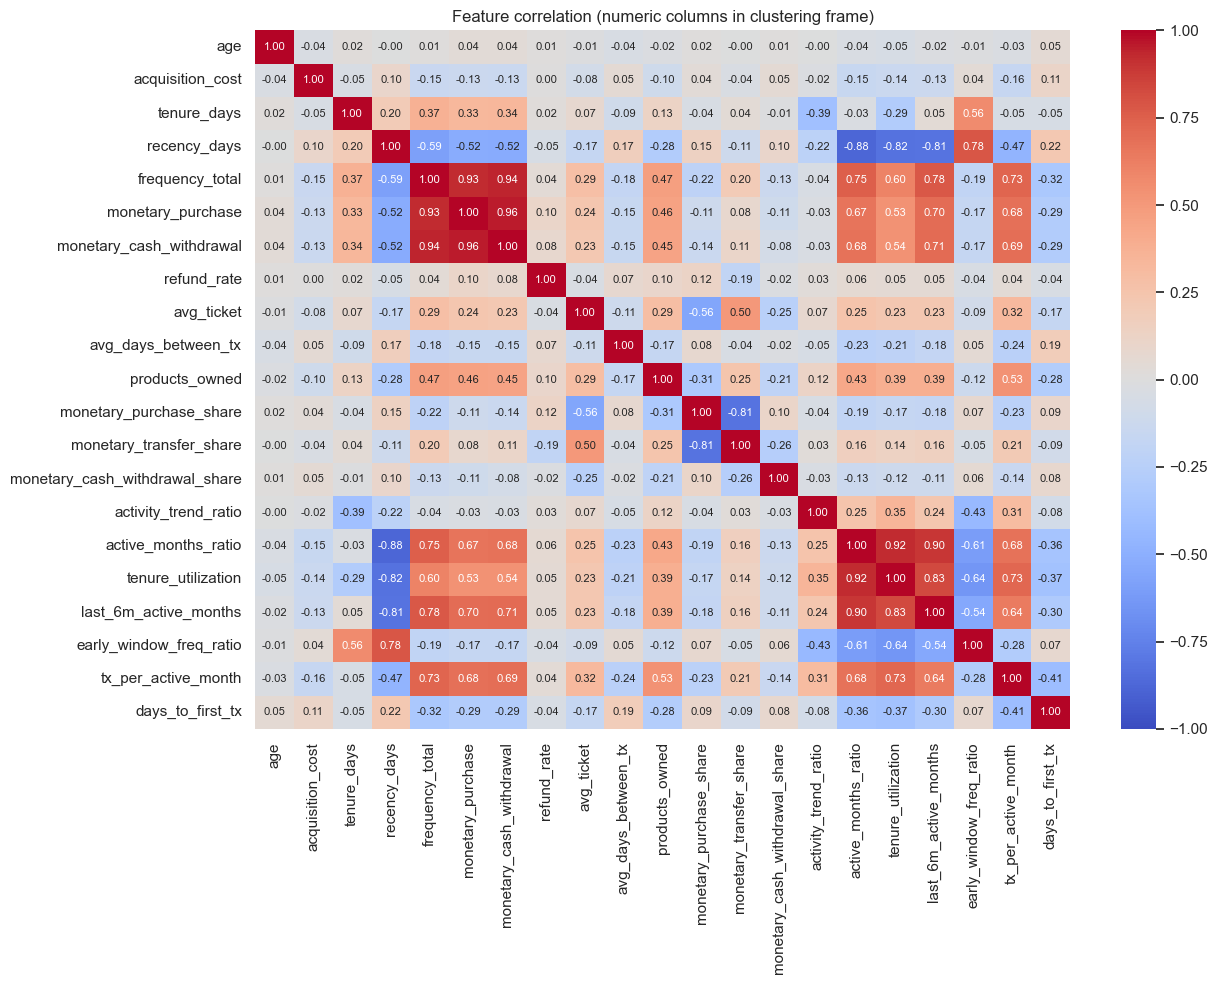

In [154]:
feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id", "monetary_total"}
]
if {"frequency_total", "avg_ticket"}.issubset(df_clustering.columns):
    corr_freq_ticket = df_clustering[["frequency_total", "avg_ticket"]].corr().iloc[0, 1]
    print(f"corr(frequency_total, avg_ticket): {corr_freq_ticket:.4f}")

_corr = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation (numeric columns in clustering frame)")
plt.tight_layout()
plt.show()


### Why we dropped these columns (multicollinearity prune)

**Raw BRL splits (`monetary_purchase`, `monetary_transfer`, `monetary_cash_withdrawal`)** — In the correlation heatmap they sit on the same axis as **`frequency_total`** (~0.93–0.96): higher activity mechanically raises counts and BRL in every type. We already keep **`frequency_total`**, **`avg_ticket`**, and **`monetary_*_share`** for *level* vs *mix*, so the raw splits double-weight “how big” the customer is in Euclidean space.

**`tenure_utilization` and `last_6m_active_months`** — Both are very highly correlated with **`active_months_ratio`** (~0.83–0.92): same idea (“how much of the window were they active / recent”). We keep **`active_months_ratio`** as the single primary “coverage” axis to avoid triple-counting engagement.

**What we did not drop** — **`recency_days`** despite negative correlation with activity ratios: that is expected opposites (recent vs dormant), not duplicate positive clones. **`monetary_*_share`** stay for compositional mix; **`early_window_freq_ratio`** and **`activity_trend_ratio`** stay for churn-shape vs steady engagement.


Dropped 4 columns: ['monetary_purchase', 'monetary_cash_withdrawal', 'tenure_utilization', 'last_6m_active_months']
Clustering feature count after prune: 17


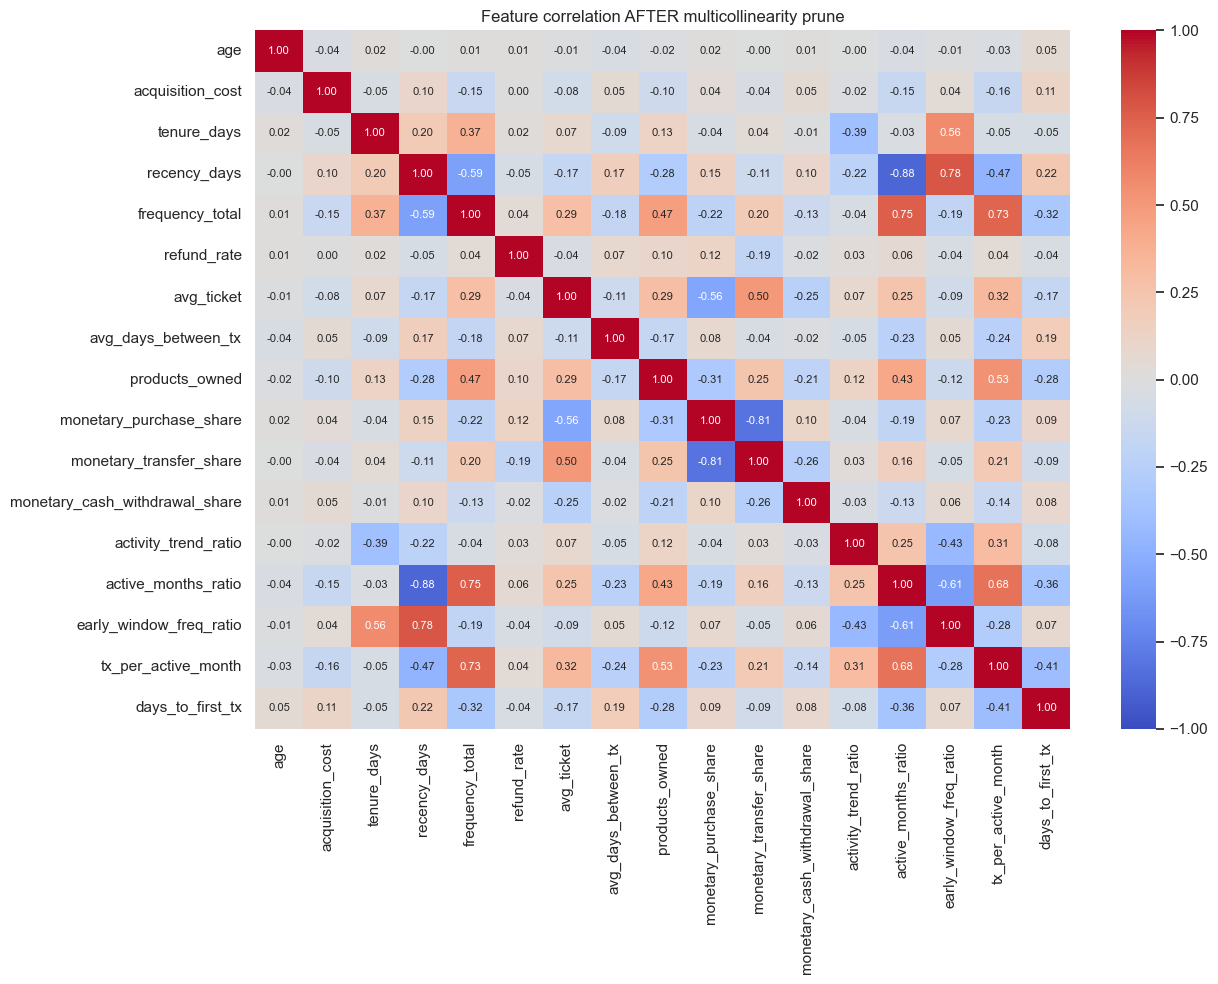

In [155]:
# Multicollinearity prune (see markdown cell below). Re-runs safe: drops only if columns exist.
_MULTICOLLINEARITY_DROP = [
    # These three were already candidates for drop_correlated_splits() (corr > 0.9
    # with monetary_total). We drop them here explicitly so the prune is visible in
    # the notebook log regardless of whether drop_correlated_splits() already removed them.
    # monetary_* splits were intentionally removed — do not fill back with 0.0.
    "monetary_purchase",    # near-perfect proxy for monetary_total when purchases dominate
    "monetary_transfer",    # same — high corr with monetary_total when transfers dominate
    "monetary_cash_withdrawal",  # same pattern; mix signal is captured by *_share columns
    # Not candidates for drop_correlated_splits() — dropped for a different reason:
    "tenure_utilization",   # alias of active_months_ratio (both = active_months / span); VIF > 10
    "last_6m_active_months",  # subsumed by active_months_ratio and activity_trend_ratio
]
_present = [c for c in _MULTICOLLINEARITY_DROP if c in df_clustering.columns]
if _present:
    df_clustering = df_clustering.drop(columns=_present)
    print(f"Dropped {len(_present)} columns: {_present}")
else:
    print("No columns from the prune list are present (already dropped or different schema).")

feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id", "monetary_total"}
]
print(f"Clustering feature count after prune: {len(feature_cols)}")

_corr_pruned = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr_pruned,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation AFTER multicollinearity prune")
plt.tight_layout()
plt.show()


### Raw distributions (before `log1p` / `sqrt`)

Skew-heavy axes (recency, frequency, ticket, …) are **not** Gaussian yet — that is expected. The preprocessing pipeline applies **`log1p`** to those columns before scaling so k-means distances are not dominated by a thin tail of extreme users.


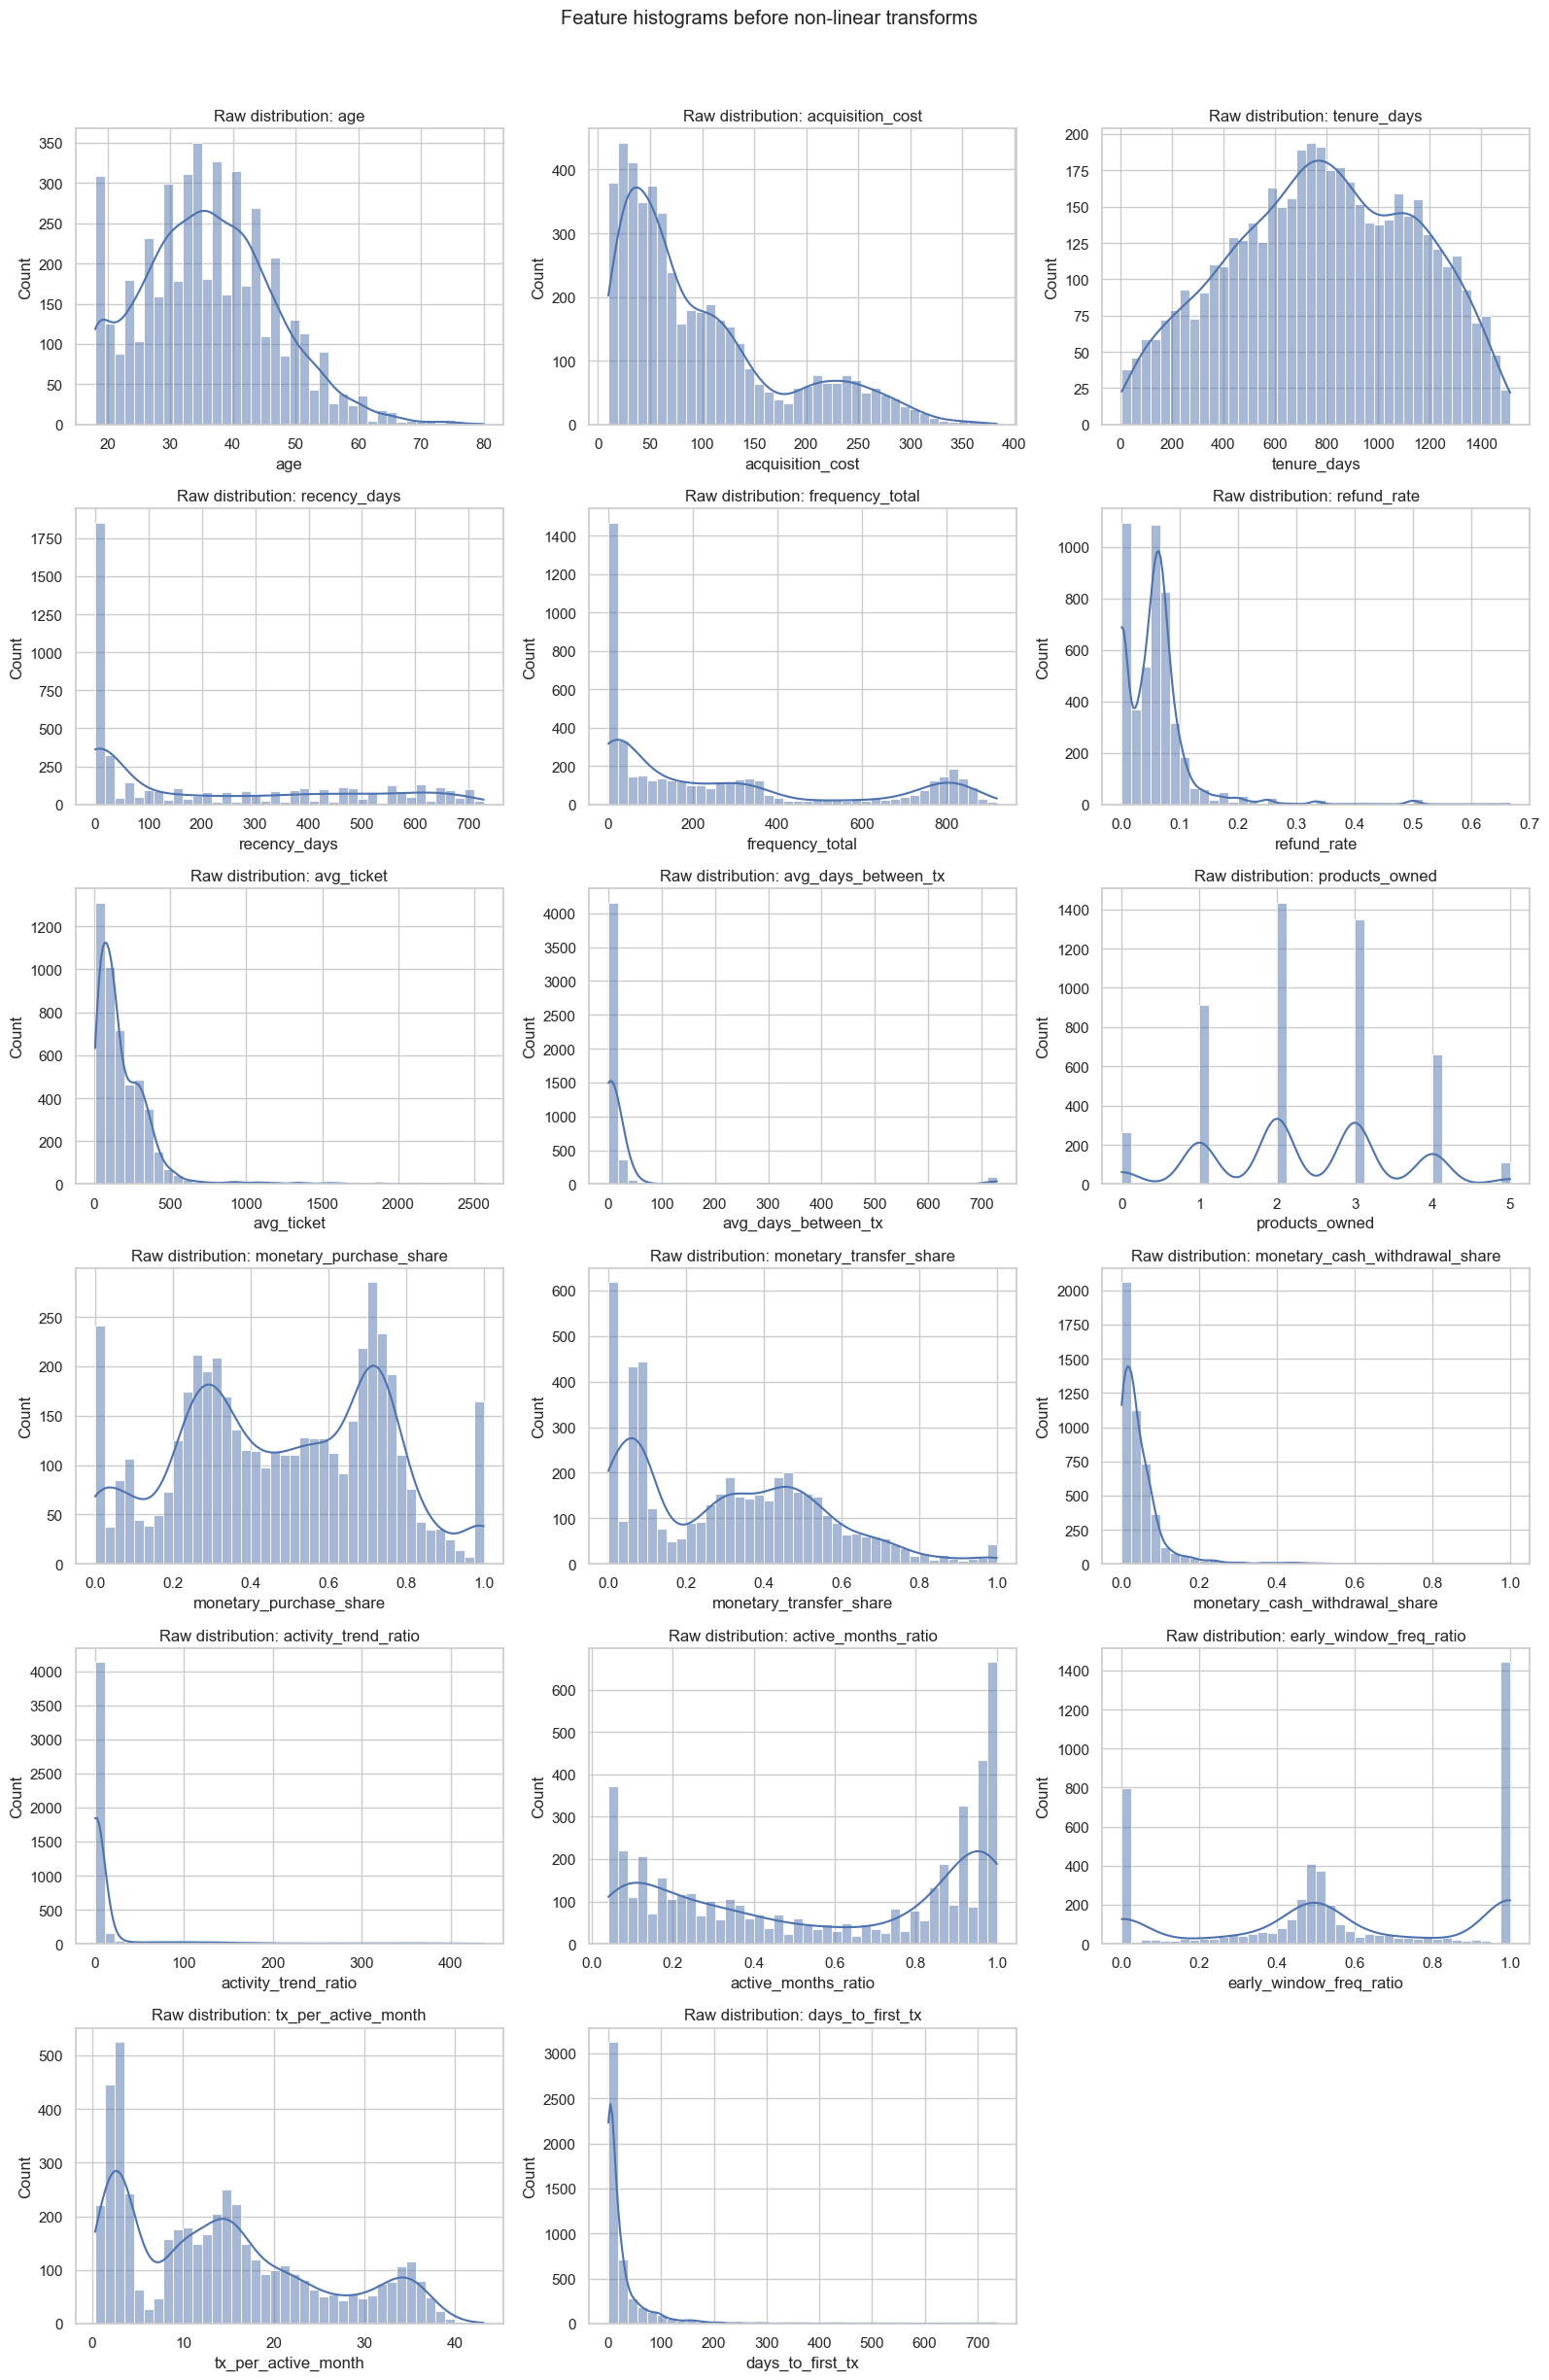

In [156]:
plot_cols = [c for c in feature_cols if c != "customer_id"]
if plot_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df_clustering[col].dropna(), bins=40, kde=True, ax=axes[i])
        axes[i].set_title(f"Raw distribution: {col}")

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature histograms before non-linear transforms", y=1.02)
    plt.tight_layout()
    plt.show()


### Preprocessing fit (`ColumnTransformer` + `StandardScaler`)

`build_preprocessing_pipeline(feature_cols)` applies **`log1p`** to right-skewed magnitudes, **`sqrt`** to bounded rate features, passes through remaining columns unchanged, then **`StandardScaler`** on **all** transformed features — required so k-means Euclidean distance is not axis-dominated by BRL scale or mixed units.

**Why these transforms?**

| Column | Transform | Rationale |
|--------|-----------|-----------|
| `recency_days` | `log1p` | Right-skewed: most customers transacted recently, a few extreme laggards |
| `frequency_total` | `log1p` | Pareto-style: few high-frequency customers dominate the raw scale |
| `avg_ticket` | `log1p` | BRL amounts vary by 2–3 orders of magnitude between segments |
| `avg_days_between_tx` | `log1p` | Same shape as recency — dominated by dormant customers |
| `acquisition_cost` | `log1p` | Multi-modal right tail (paid_ads vs organic differ by 10×) |
| `activity_trend_ratio` | `log1p` | Right-skewed ratio — growing customers can have ratios >> 1 |
| `refund_rate` | `sqrt` | Bounded [0, 1] with a spike at 0; lighter skew than log1p requires |
| `products_owned` | passthrough | Integer count, low variance, already on a natural scale |
| `age`, `tenure_days` | passthrough | Approximately normal; StandardScaler handles the scale difference |
| `active_months_ratio` | passthrough | Already bounded [0, 1] — no transform needed |
| `tenure_utilization` | passthrough | Same — bounded ratio |
| `monetary_*_share` | passthrough | Compositional shares [0, 1] — no transform needed |

`LOG1P_COLS` and `SQRT_COLS` are defined in `rfm_features.py` and drive the `ColumnTransformer` step inside `build_preprocessing_pipeline`. The pipeline is deterministic given the same feature list.


In [157]:
preproc = build_preprocessing_pipeline(feature_cols)
X_scaled = preproc.fit_transform(df_clustering[feature_cols])

print("X_scaled shape:", X_scaled.shape)

log_cols = [c for c in rfm.LOG1P_COLS if c in feature_cols]
sqrt_cols = [c for c in rfm.SQRT_COLS if c in feature_cols and c not in log_cols]
pass_cols = [c for c in feature_cols if c not in log_cols and c not in sqrt_cols]
out_cols = log_cols + sqrt_cols + pass_cols

scaled_preview = pd.DataFrame(X_scaled, columns=out_cols)
display(scaled_preview.describe().T[["mean", "std", "min", "max"]].head(12))
display(df_clustering.head())


X_scaled shape: (4727, 17)


,mean,std,min,max
recency_days,-9.620211e-17,1.000106,-1.360408,1.183511
frequency_total,2.405053e-16,1.000106,-2.025174,1.272833
avg_ticket,5.772126e-16,1.000106,-3.130985,3.135175
avg_days_between_tx,1.443032e-16,1.000106,-1.178151,4.213990
acquisition_cost,-3.006316e-16,1.000106,-2.186064,2.001074
activity_trend_ratio,0.000000e+00,1.000106,-0.763133,3.744103
tx_per_active_month,9.620211e-17,1.000106,-2.401062,1.581519
days_to_first_tx,4.810105e-17,1.000106,-1.419671,2.905462
refund_rate,-4.810105e-17,1.000106,-1.584832,4.814136
age,1.262653e-16,1.000106,-1.702591,4.142721


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,refund_rate,avg_ticket,avg_days_between_tx,products_owned,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share,activity_trend_ratio,active_months_ratio,early_window_freq_ratio,tx_per_active_month,days_to_first_tx
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,27.79,981.0,0.0,822.0,256949.14,0.065909,312.590195,0.888412,3.0,0.290197,0.497311,0.030303,0.911833,1.000000,0.523114,25.506300,0.0
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,222.02,882.0,0.0,770.0,179638.74,0.070048,233.297065,0.948615,4.0,0.407612,0.294093,0.037990,1.000000,0.918628,0.500000,28.928571,1.0
2,a98bdb67-7583-46ec-9597-edbbad7e826e,32,39.81,1255.0,0.0,791.0,110349.42,0.054958,139.506220,0.923584,2.0,0.718133,0.076748,0.066789,1.137466,0.960384,0.467762,19.977100,0.0
3,27044599-8351-4735-accb-36881f9b0781,40,52.54,1029.0,0.0,789.0,170560.22,0.058473,216.172649,0.925468,4.0,0.440926,0.277067,0.040691,1.137838,0.960384,0.467681,24.303080,0.0
4,f05b6038-ad20-4708-8dcf-346473ab2942,33,199.99,866.0,4.0,800.0,250996.50,0.038462,313.745625,0.908084,3.0,0.289714,0.439903,0.022902,0.960880,0.960384,0.510000,29.280048,0.0


**Definitions (feature matrix for clustering)** — All features are numeric.

**Behavioral (RFM):** `recency_days`, `frequency_total`, `avg_ticket`, `avg_days_between_tx`, `refund_rate`, `products_owned`.

**Customer attributes:** `age`, `acquisition_cost` (channel-quality proxy), `tenure_days`.

**Spend mix:** `monetary_purchase_share`, `monetary_transfer_share`, `monetary_cash_withdrawal_share`.

**Trajectory** (captures engagement evolution over the 24-month window):
- `activity_trend_ratio` = (recent-half tx + 1) / (early-half tx + 1). **log1p**. Values < 1 → declining (churner); ≈ 1 → stable; > 1 → growing.
- `active_months_ratio` = active calendar months / months since first tx. **passthrough** [0, 1]. Primary “coverage” axis (replaces overlapping `tenure_utilization` / `last_6m_active_months`, which are dropped before clustering — see multicollinearity prune).
- `early_window_freq_ratio` = share of all window tx that fell in the FIRST half. **passthrough** [0, 1]. Churners front-load (→ 1.0); stable customers → 0.5.

**Derived intensity:**
- `tx_per_active_month` = frequency_total / active_months_approx. **log1p**. Encodes per-segment intensity when active: high ~40, mid ~18, dormant ~4, churner ~2.
- `days_to_first_tx` = days from registration to first ever transaction (full history). **log1p**. Quick activators: 0–30 d; slow/never: 200+ d.

**Exclusions:** `monetary_total` (diagnostic only), `true_segment` (ground-truth label to recover), `state`, `acquisition_channel`.

**Dropped before clustering (redundant axes):** raw BRL splits `monetary_purchase`, `monetary_transfer`, `monetary_cash_withdrawal` (level already captured by `frequency_total` + `avg_ticket` + shares), plus `tenure_utilization` and `last_6m_active_months` (near-collinear with `active_months_ratio`).


<a id="part-3"></a>

## Part 3 — K-means: choosing **k** and profiling clusters

**Goal:** evaluate cluster structure for **`k = 2..7`** using internal clustering diagnostics: **inertia** (elbow intuition), **mean silhouette** (separation quality), **Davies-Bouldin** (compactness/separation; lower is better), and **Calinski-Harabasz** (between-vs-within dispersion; higher is better). We also inspect **silhouette diagrams** per **`k`**.


### Feature ablation & PCA experiment — finding the best input set

**Why ablation?** K-means Euclidean distance treats every scaled feature dimension equally. Adding features that carry no segment-separation signal (e.g. `age`, `acquisition_cost`) adds noise to distances and can shrink the silhouette score. We test four configurations to find the input set that maximises cluster separation:

| Config | Features | Notes |
|--------|----------|-------|
| `full` | All scaled features | Current default — includes demographics |
| `core` | RFM + trajectory only | Drops `refund_rate`, `acquisition_cost`, `age` |
| `pca_full` | PCA on `full` (≥ 90 % variance) | Removes noise dimensions via compression |
| `pca_core` | PCA on `core` (≥ 90 % variance) | Core set + PCA compression |

**Demographic features as noise:** `age`, `acquisition_cost`, and `refund_rate` describe *who* a customer is and *how they were acquired*, but segments are defined by *behavioral patterns* (activity rate, spend trajectory, product usage). Demographics may correlate weakly with segments but add irrelevant axes that pull centroids toward high-spend or older-registration customers independent of their behavioral cluster.

**Selection rule:** the configuration with the highest mean silhouette score across k ∈ {2, 3, 4} is selected. Silhouette is scale-invariant and measures cohesion vs. separation, making it appropriate for comparing across feature sets with different dimensionalities. Ties (within 0.002) are broken by Davies-Bouldin (lower is better).


In [158]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

_NOISE_FEATURES = {"refund_rate", "acquisition_cost", "age"}

def _eval_kmeans(X, k=3, n_init=20, seed=42):
    km = KMeans(n_clusters=k, random_state=seed, n_init=n_init)
    lbl = km.fit_predict(X)
    return {
        "silhouette": silhouette_score(X, lbl),
        "davies_bouldin": davies_bouldin_score(X, lbl),
        "calinski_harabasz": calinski_harabasz_score(X, lbl),
        "labels": lbl,
    }

def _pca_reduce(X, var_threshold=0.90):
    pca = PCA(random_state=42)
    pca.fit(X)
    cumvar = pca.explained_variance_ratio_.cumsum()
    n_comp = int((cumvar >= var_threshold).argmax()) + 1
    return PCA(n_components=n_comp, random_state=42).fit_transform(X), n_comp

# ── Build core feature set (drop demographic noise) ──────────────────────────
core_feature_cols = [c for c in feature_cols if c not in _NOISE_FEATURES]

preproc_core = build_preprocessing_pipeline(core_feature_cols)
X_core = preproc_core.fit_transform(df_clustering[core_feature_cols])

# ── PCA reductions ────────────────────────────────────────────────────────────
X_pca_full, n_pca_full = _pca_reduce(X_scaled)
X_pca_core, n_pca_core = _pca_reduce(X_core)

print(f"core_feature_cols ({len(core_feature_cols)}): {core_feature_cols}")
print(f"PCA(full): {X_scaled.shape[1]} → {n_pca_full} components")
print(f"PCA(core): {X_core.shape[1]} → {n_pca_core} components")

core_feature_cols (14): ['tenure_days', 'recency_days', 'frequency_total', 'avg_ticket', 'avg_days_between_tx', 'products_owned', 'monetary_purchase_share', 'monetary_transfer_share', 'monetary_cash_withdrawal_share', 'activity_trend_ratio', 'active_months_ratio', 'early_window_freq_ratio', 'tx_per_active_month', 'days_to_first_tx']
PCA(full): 17 → 9 components
PCA(core): 14 → 7 components


With helper functions and feature matrices ready, we evaluate each configuration across k ∈ {2, 3, 4}. The loop records silhouette, Davies-Bouldin, and Calinski-Harabasz for each combination. **The global best (max silhouette across all k and configs) is selected as `best_config`** and used for all downstream k=2..7 evaluation and the final model fit.

In [159]:
# ── Evaluate across k ∈ {2, 3, 4} ─────────────────────────────────────────────
K_RANGE = [2, 3, 4]

def _nfeat_for_config(name: str) -> int:
    if name == "full":
        return X_scaled.shape[1]
    if name == "core":
        return X_core.shape[1]
    if name == "pca_full":
        return n_pca_full
    if name == "pca_core":
        return n_pca_core
    raise ValueError(name)

configs = {
    "full": X_scaled,
    "core": X_core,
    "pca_full": X_pca_full,
    "pca_core": X_pca_core,
}

rows_ab = []
for k in K_RANGE:
    for name, Xmat in configs.items():
        res = _eval_kmeans(Xmat, k=k)
        rows_ab.append({
            "k": k,
            "config": name,
            "n_features": _nfeat_for_config(name),
            "n_pca_note": n_pca_full if name == "pca_full" else (n_pca_core if name == "pca_core" else "—"),
            "silhouette": round(res["silhouette"], 4),
            "davies_bouldin": round(res["davies_bouldin"], 4),
            "calinski_harabasz": round(res["calinski_harabasz"], 1),
        })

df_ablation = pd.DataFrame(rows_ab)
print(f"=== Feature ablation & PCA experiment (k ∈ {K_RANGE}) ===")
display(df_ablation.sort_values(["k", "silhouette"], ascending=[True, False]))

# Best config per k (by silhouette)
for k in K_RANGE:
    sub = df_ablation[df_ablation["k"] == k]
    best_row = sub.loc[sub["silhouette"].idxmax()]
    print(
        f"Best @ k={k}: '{best_row['config']}'  "
        f"(silhouette={best_row['silhouette']:.4f})"
    )

# Global best (max silhouette across all k and configs)
best_row = df_ablation.loc[df_ablation["silhouette"].idxmax()]
best_config = str(best_row["config"])  # "full" | "core" | "pca_full" | "pca_core"
best_k_ablation = int(best_row["k"])
print(
    f"\nGlobal best: k={best_k_ablation}, config='{best_config}'  "
    f"(silhouette={best_row['silhouette']:.4f})"
)

=== Feature ablation & PCA experiment (k ∈ [2, 3, 4]) ===


,k,config,n_features,n_pca_note,silhouette,davies_bouldin,calinski_harabasz
3,2,pca_core,7,7,0.3097,1.3319,2355.2
1,2,core,14,—,0.2869,1.4277,2075.0
2,2,pca_full,9,9,0.2728,1.5085,1896.3
0,2,full,17,—,0.2514,1.6237,1650.1
5,3,core,14,—,0.2591,1.3421,1574.3
7,3,pca_core,7,7,0.2400,1.4691,1810.6
6,3,pca_full,9,9,0.1897,1.6889,1406.6
4,3,full,17,—,0.1674,1.8315,1211.1
11,4,pca_core,7,7,0.2595,1.3753,1697.4
9,4,core,14,—,0.2360,1.4913,1450.6


Best @ k=2: 'pca_core'  (silhouette=0.3097)
Best @ k=3: 'core'  (silhouette=0.2591)
Best @ k=4: 'pca_core'  (silhouette=0.2595)

Global best: k=2, config='pca_core'  (silhouette=0.3097)


In [160]:
# Apply best config from ablation experiment
# "Best" = highest silhouette score across all k and configs in df_ablation.
# We re-run the k=2..7 scan with this config so elbow/silhouette charts
# reflect the chosen feature space — not the full-feature default.
if "best_row" not in globals() and "df_ablation" in globals():
    best_row = df_ablation.loc[df_ablation["silhouette"].idxmax()]
if "best_row" not in globals():
    raise RuntimeError("Run the feature ablation cell above first (defines df_ablation + best_row).")
if "best_config" not in globals():
    best_config = str(best_row["config"])

BEST_FEATURE_CONFIG = best_config
_best_sil = float(best_row["silhouette"])

if BEST_FEATURE_CONFIG == "pca_full":
    X_for_km = X_pca_full
    print(f"Using PCA (full features → {n_pca_full} components, silhouette={_best_sil:.4f})")
elif BEST_FEATURE_CONFIG == "pca_core":
    X_for_km = X_pca_core
    print(f"Using PCA (core features → {n_pca_core} components, silhouette={_best_sil:.4f})")
elif BEST_FEATURE_CONFIG == "core":
    X_for_km = X_core
    print(f"Using core features ({X_core.shape[1]} features, silhouette={_best_sil:.4f})")
else:
    X_for_km = X_scaled   # default: full features
    print(f"Using full scaled features ({X_scaled.shape[1]} features, silhouette={_best_sil:.4f})")

# Also re-run the k=2..7 scan with the best config so the elbow/silhouette charts
# reflect the chosen feature space
k_values_scan = list(range(2, 8))
rows_scan = []
labels_by_k_best = {}
for k in k_values_scan:
    km_s = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl_s = km_s.fit_predict(X_for_km)
    labels_by_k_best[k] = lbl_s
    rows_scan.append({
        "k": k,
        "inertia": float(km_s.inertia_),
        "silhouette": float(silhouette_score(X_for_km, lbl_s)),
        "davies_bouldin": float(davies_bouldin_score(X_for_km, lbl_s)),
        "calinski_harabasz": float(calinski_harabasz_score(X_for_km, lbl_s)),
    })

k_eval_best = pd.DataFrame(rows_scan)
k_eval_best["inertia_drop_pct"] = (k_eval_best["inertia"].shift(1) - k_eval_best["inertia"]) / k_eval_best["inertia"].shift(1)
display(k_eval_best[["k","silhouette","davies_bouldin","calinski_harabasz"]].round(4))


Using PCA (core features → 7 components, silhouette=0.3097)


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.3097,1.3319,2355.1677
1,3,0.2400,1.4691,1810.5649
2,4,0.2595,1.3753,1697.4258
3,5,0.2481,1.2568,1550.4889
4,6,0.2602,1.3803,1480.2143
5,7,0.2701,1.2711,1459.8795


In [161]:
# k=2..7 evaluation using the best feature configuration from ablation experiment
# (k_eval_best and labels_by_k_best are already computed in the apply-best cell above)
k_eval     = k_eval_best         # for downstream cells that reference k_eval
labels_by_k = labels_by_k_best   # for downstream silhouette diagrams

k_eval["inertia_prev"] = k_eval["inertia"].shift(1)
k_eval["inertia_drop_pct"] = (
    (k_eval["inertia_prev"] - k_eval["inertia"]) / k_eval["inertia_prev"]
)

k_silhouette_max = int(k_eval.loc[k_eval["silhouette"].idxmax(), "k"])
k_dbi_min        = int(k_eval.loc[k_eval["davies_bouldin"].idxmin(), "k"])
k_ch_max         = int(k_eval.loc[k_eval["calinski_harabasz"].idxmax(), "k"])
k_selected       = 4   # ground-truth count of segments

display(
    k_eval[["k","inertia","inertia_drop_pct","silhouette","davies_bouldin","calinski_harabasz"]]
    .sort_values("k")
    .reset_index(drop=True)
)
print("Silhouette-max k:", k_silhouette_max)
print("Davies-Bouldin-min k:", k_dbi_min)
print("Calinski-Harabasz-max k:", k_ch_max)
print("Operational k_selected:", k_selected)

# Import needed metrics for silhouette diagrams in later cells
from sklearn.metrics import silhouette_samples


,k,inertia,inertia_drop_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,40497.022084,NaN,0.309733,1.331933,2355.167735
1,3,34351.156778,0.151761,0.240044,1.469085,1810.564906
2,4,29199.814956,0.149961,0.259515,1.375251,1697.425819
3,5,26230.745538,0.101681,0.248145,1.256755,1550.488877
4,6,23633.156913,0.099028,0.260183,1.380268,1480.214272
5,7,21249.088241,0.100878,0.270115,1.271134,1459.879527


Silhouette-max k: 2
Davies-Bouldin-min k: 5
Calinski-Harabasz-max k: 2
Operational k_selected: 4


### Elbow and mean silhouette (line charts)

Use these plots together: the **elbow** is often ambiguous on marketing/behavioral data; **mean silhouette** penalises overlap but can favour **too few** clusters. The next subsection shows **full silhouette blades** per **`k`** (per-sample coefficients).


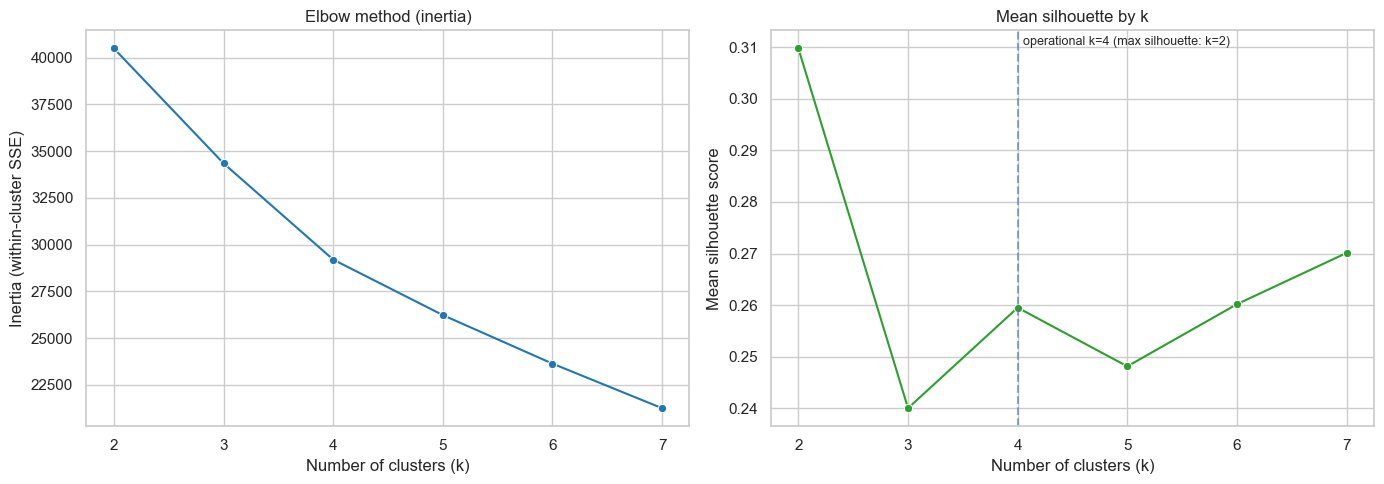

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

sns.lineplot(
    data=k_eval,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
    color="#2ca02c",
)
axes[1].set_title("Mean silhouette by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Mean silhouette score")
axes[1].axvline(k_selected, linestyle="--", alpha=0.6)
axes[1].text(
    k_selected + 0.05,
    k_eval["silhouette"].max(),
    f"operational k={k_selected} (max silhouette: k={k_silhouette_max})",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()


### Silhouette diagrams per k (full coefficient profiles)

Each panel sorts samples by cluster blocks. The vertical dashed line is the **mean** silhouette for that **`k`**. Use this to spot **over-splitting** (many small negative slices) vs **stable** separation.


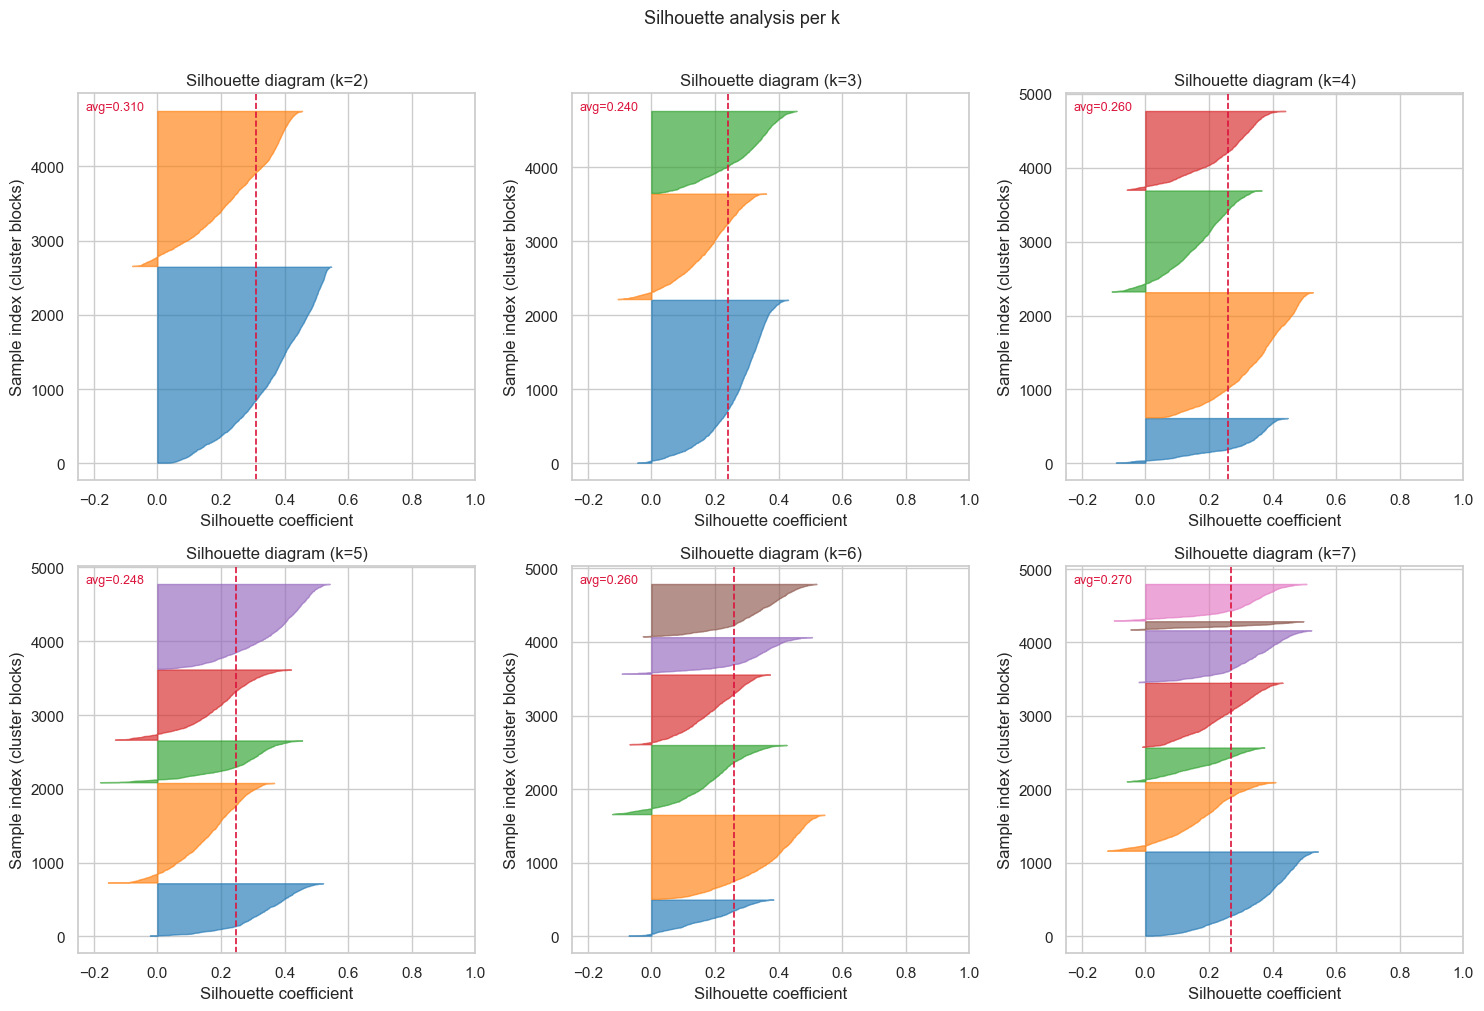

In [163]:
fig_sil, axes_sil = plt.subplots(2, 3, figsize=(15, 10))
axes_sil = axes_sil.flatten()

for ax_idx, k in enumerate(k_values_scan):
    ax = axes_sil[ax_idx]
    cluster_labels = labels_by_k[k]
    sil_avg = float(k_eval.loc[k_eval["k"] == k, "silhouette"].iloc[0])
    sample_silhouette_values = silhouette_samples(X_for_km, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(i % 10)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.65,
        )
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_title(f"Silhouette diagram (k={k})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Sample index (cluster blocks)")
    ax.set_xlim(-0.25, 1.0)
    ax.text(
        0.02,
        0.98,
        f"avg={sil_avg:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        color="crimson",
    )

plt.suptitle("Silhouette analysis per k", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


### Chart interpretation — elbow, mean silhouette, and silhouette diagrams

**Elbow (inertia)** — Inertia always decreases as **`k`** increases. Look for **diminishing returns** (successive merges of inertia drops), but behavioral datasets often yield a **soft** elbow.

**Mean silhouette** — Summarises how cleanly points match their nearest cluster vs neighbours. Higher is better, but the maximising **`k`** can be **too coarse** for CRM actions.

**Silhouette diagrams** — Reveal **per-cluster** weakness: wide negative mass in a cluster means that group is not well-separated in the current feature space.

**Decision (this notebook):** We lock **`k = 4`** because the synthetic data was explicitly built with **4 ground-truth segments** (`high_value_active`, `mid_value_regular`, `low_value_dormant`, `at_risk_churner`). Internal metrics help confirm that k=4 is geometrically reasonable (not an outlier on silhouette / DBI / CH), but the authoritative criterion is segment recovery — validated in Part 6.


> **How to choose k on real data (without planted segments):**
> 1. Rule out clearly under-separated clusters using silhouette diagrams — if a cluster has substantial negative mass, it is absorbing points that belong elsewhere.
> 2. Prefer k where the silhouette diagram shows clusters of roughly equal width (balanced assignment) with no large negative bars.
> 3. Davies-Bouldin should be low; Calinski-Harabasz should be high — use these to break ties when silhouette is flat across k.
> 4. Elbow plots on behavioral data are almost always ambiguous — treat inertia as a sanity check, not a selection criterion.
> 5. Apply a business lens: does k=X produce segments with meaningfully different action implications (high-touch vs. automated vs. win-back vs. nurture)? If two clusters prescribe identical actions, merge them.


### Decision checkpoint — fit k-means at operational k

We fit **one** production-style model at **`k = k_selected = 4`**, assign **`cluster_km`**, and profile clusters below (PCA is **visualisation only** — not used to fit k-means).


In [164]:
k_fit = int(k_selected)   # 4
km_fit = KMeans(n_clusters=k_fit, random_state=42, n_init=20)
labels_km = km_fit.fit_predict(X_for_km)

df_clustering = df_clustering.copy()
df_clustering["cluster_km"] = labels_km

cluster_sizes = (
    df_clustering["cluster_km"].value_counts().sort_index().rename("n_customers")
)
print(f"Cluster sizes (k={k_fit}) [{BEST_FEATURE_CONFIG} features]:")
print(cluster_sizes.to_string())

final_sil = silhouette_score(X_for_km, labels_km)
print(f"\nFinal k=4 silhouette ({BEST_FEATURE_CONFIG}): {final_sil:.4f}")


Cluster sizes (k=4) [pca_core features]:
cluster_km
0     604
1    1692
2    1365
3    1066

Final k=4 silhouette (pca_core): 0.2595


### Visualising clusters (PCA for 2D projection + feature profiles)

Two complementary views:

- **2D PCA scatter** of **`X_for_km`** — this is the **same matrix K-Means used** (e.g. full/core scaled features, or **already an \(N\)-component PCA embedding** when `BEST_FEATURE_CONFIG` is `pca_full` / `pca_core`). For those PCA configs, \(N\) can be **8 for `pca_core`** (90% variance rule) while the plot is only **PC1 vs PC2 of a second PCA(2)** fit on that embedding for drawing — the % in the title is variance along those two display axes within the clustering input space, not “% of all raw features.”
- **Boxplots** on interpretable **raw** columns in `df_clustering` — primary business readout (clusters were not built on these directly unless you chose the full non-PCA set).


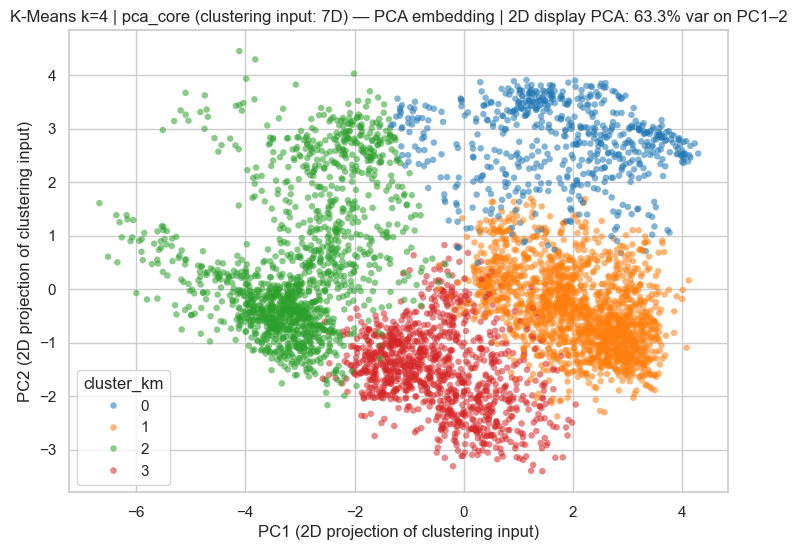

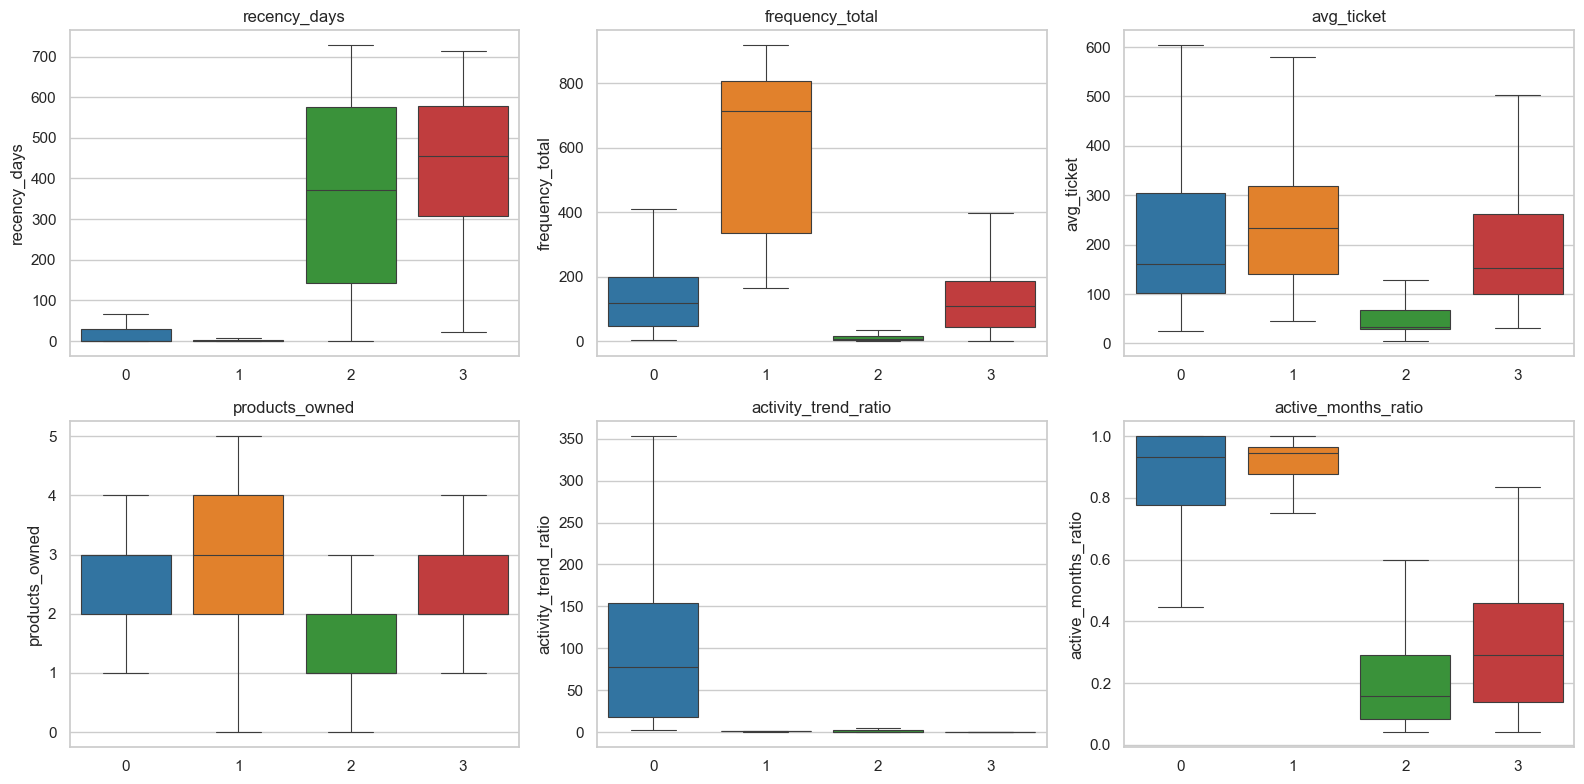

In [165]:
from sklearn.decomposition import PCA

plot_df = df_clustering.copy()

pca2d = PCA(n_components=2, random_state=42)
X_pca = pca2d.fit_transform(X_for_km)
plot_df["pc1"] = X_pca[:, 0]
plot_df["pc2"] = X_pca[:, 1]

fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))

# PCA scatter — cluster_km
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="cluster_km",
    palette="tab10",
    alpha=0.55,
    s=22,
    linewidth=0,
    ax=ax,
)
_d_in = X_for_km.shape[1]
_viz_pct = pca2d.explained_variance_ratio_.sum() * 100
ax.set_title(
    f"K-Means k={k_fit} | {BEST_FEATURE_CONFIG} (clustering input: {_d_in}D)"
    + (" — PCA embedding" if str(BEST_FEATURE_CONFIG).startswith("pca") else "")
    + f" | 2D display PCA: {_viz_pct:.1f}% var on PC1–2"
)
ax.set_xlabel("PC1 (2D projection of clustering input)")
ax.set_ylabel("PC2 (2D projection of clustering input)")
ax.legend(title="cluster_km")

# Feature profile — one boxplot per listed column (7 plots = 7 features that exist in df_clustering)
feature_view = [c for c in ["recency_days", "frequency_total", "avg_ticket",
                             "products_owned", "activity_trend_ratio",
                             "active_months_ratio", "tenure_utilization"] if c in df_clustering.columns]
n_f = len(feature_view)
n_rows_f = (n_f + 2) // 3

fig2, axes2 = plt.subplots(n_rows_f, 3, figsize=(16, 4 * n_rows_f))
axes2 = axes2.flatten()
for ax_i, col in enumerate(feature_view):
    ax = axes2[ax_i]
    sns.boxplot(
        data=df_clustering,
        x="cluster_km",
        y=col,
        hue="cluster_km",
        palette="tab10",
        legend=False,
        showfliers=False,
        ax=ax,
        linewidth=0.8,
    )
    ax.set_title(col)
    ax.set_xlabel("")
for ax_i in range(len(feature_view), len(axes2)):
    axes2[ax_i].set_visible(False)

plt.tight_layout()
plt.show()


### Brief read of k-means results (k = 4)

The `k=4` solution is designed to recover the four planted behavioral segments:

- **Engaged/high-frequency cluster** (`high_value_active`) — low recency, high frequency, high avg_ticket, many products, high trajectory scores. This cluster is typically the most compact (highest per-cluster silhouette) because spend and frequency jointly dominate distance.
- **Regular/moderate cluster** (`mid_value_regular`) — active monthly but lower intensity than the top group. Distinguished primarily by frequency (≈ 18 tx/month vs ≈ 40) and avg_ticket (≈ R$160 vs R$220).
- **Dormant cluster** (`low_value_dormant`) — sparse activity across the full 24-month window. `activity_trend_ratio` is near 1.0 (low activity in both halves), `active_months_ratio` is low. These customers were never highly engaged — they are not declining, just perpetually low-frequency.
- **Churner cluster** (`at_risk_churner`) — the most diagnostically important segment. **`activity_trend_ratio` occupies the negative tail** (values well below 1.0): these customers concentrated all activity in the first half of the 24-month window and fell silent in the second half. They look similar to dormant customers on a snapshot RFM view, but their trajectory reveals a *transition* — from moderate engagement to disengagement. This is the early-warning churn signal.

Cluster IDs (0/1/2/3) are arbitrary labels. Interpret them by feature medians in the boxplots above and confirm against `true_segment` in Part 6.


### Deep-dive plan: product penetration and activity gap by cluster

To better understand the business potential inside each of the **k=4 clusters**, we profile them on two product dimensions:

1. **Penetration** — what share of customers in the cluster **own** each product (point-in-time snapshot at `as_of_date`).
2. **Activity (last 6 months)** — what share made **at least one transaction** in each product within the 6-month period before `as_of_date`.
3. **Gap** — `penetration - activity`: customers who own a product but haven't used it recently. This is the primary activation opportunity metric.

**Why 6 months?** The 6-month horizon aligns with the **M6 cohort window** used in Notebook 2 (cohort analysis), where M6 first-month-active rate was the primary channel quality signal. A customer who owns a product but made no transaction in 6 months is effectively inactive in that product — below the threshold we'd consider "regularly engaged." Shorter windows (e.g. 3 months) would over-penalise seasonal products; longer windows (12 months) would miss customers in the early stages of disengagement.


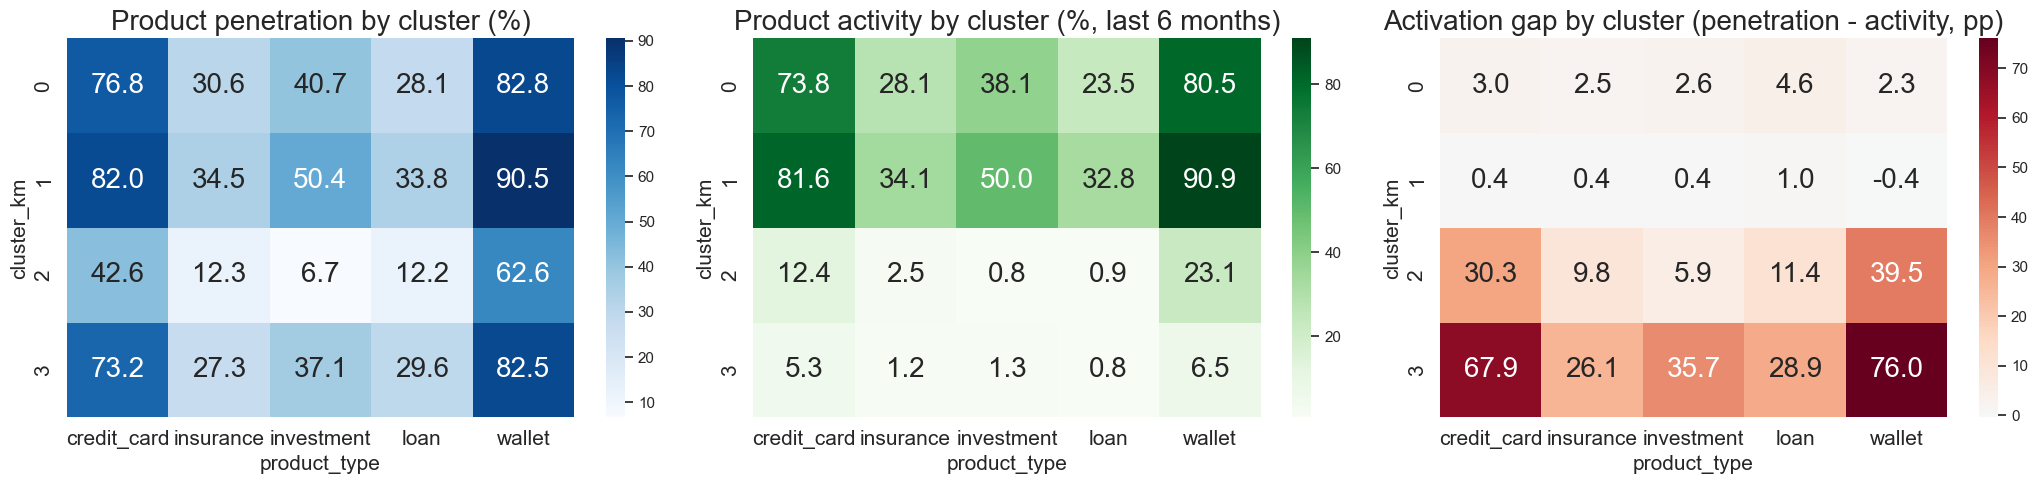

In [166]:
# K-means clusters (k=4) business read: product penetration + product activity gap

# 0) Resolve cluster assignment
if "df_clustering" not in globals():
    raise ValueError("df_clustering not found. Run Part 4 (k-means clustering) first.")

if "cluster_km" not in df_clustering.columns:
    if "labels_km" in globals() and len(labels_km) == len(df_clustering):
        df_clustering = df_clustering.copy()
        df_clustering["cluster_km"] = labels_km
    else:
        raise ValueError("cluster_km not found in df_clustering and labels_km is unavailable.")

cluster_map = df_clustering[["customer_id", "cluster_km"]].copy()

# 1) Product penetration (ownership) by cluster
cp_active = df_customer_products.copy()
if "is_active" in cp_active.columns:
    cp_active = cp_active[cp_active["is_active"] == True].copy()

cp_prod = cp_active.merge(df_products[["product_id", "product_type"]], on="product_id", how="left")
own_pairs = cp_prod[["customer_id", "product_type"]].dropna().drop_duplicates()

# Build full customer x product grid to keep the denominator correct.
# Without this grid, rates are inflated because only observed pairs are averaged.
all_product_types = sorted(df_products["product_type"].dropna().unique().tolist())
customer_product_base = (
    cluster_map.assign(_k=1)
    .merge(pd.DataFrame({"product_type": all_product_types, "_k": 1}), on="_k", how="left")
    .drop(columns="_k")
)

owner_flags = customer_product_base.merge(
    own_pairs.assign(owner_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
owner_flags["owner_flag"] = owner_flags["owner_flag"].fillna(0)

penetration = (
    owner_flags.groupby(["cluster_km", "product_type"], as_index=False)["owner_flag"]
    .mean()
    .rename(columns={"owner_flag": "penetration_rate"})
)
penetration["penetration_rate"] *= 100

# 2) Product activity by cluster (has >=1 tx in product_type over last 6 months)
# Anchor on as_of_date; fallback to max df_tx timestamp if as_of_date is unavailable.
_as_of = pd.Timestamp(as_of_date) if "as_of_date" in globals() else pd.Timestamp(df_tx["transaction_datetime"].max())
if _as_of.tzinfo is not None:
    _as_of = _as_of.tz_convert(None)  # tz_localize raises TypeError on tz-aware Timestamps

window_start_6m = _as_of - pd.DateOffset(months=6)

tx_recent_6m = df_tx.copy()
tx_recent_6m["transaction_datetime"] = pd.to_datetime(tx_recent_6m["transaction_datetime"], errors="coerce")
if isinstance(tx_recent_6m["transaction_datetime"].dtype, pd.DatetimeTZDtype):
    tx_recent_6m["transaction_datetime"] = tx_recent_6m["transaction_datetime"].dt.tz_convert("UTC").dt.tz_localize(None)

tx_recent_6m = tx_recent_6m[
    tx_recent_6m["transaction_datetime"].between(window_start_6m, _as_of, inclusive="both")
].copy()

activity_pairs = tx_recent_6m[["customer_id", "product_type"]].dropna().drop_duplicates()
activity_flags = customer_product_base.merge(
    activity_pairs.assign(active_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
activity_flags["active_flag"] = activity_flags["active_flag"].fillna(0)

activity = (
    activity_flags.groupby(["cluster_km", "product_type"], as_index=False)["active_flag"]
    .mean()
    .rename(columns={"active_flag": "activity_rate"})
)
activity["activity_rate"] *= 100

# 3) Gap table (penetration - activity)
prod_gap = penetration.merge(activity, on=["cluster_km", "product_type"], how="outer").fillna(0.0)
prod_gap["gap_pen_minus_act"] = prod_gap["penetration_rate"] - prod_gap["activity_rate"]

gap_pivot = prod_gap.pivot(index="cluster_km", columns="product_type", values="gap_pen_minus_act")
pen_pivot = prod_gap.pivot(index="cluster_km", columns="product_type", values="penetration_rate")
act_pivot = prod_gap.pivot(index="cluster_km", columns="product_type", values="activity_rate")

#print("Product penetration by cluster (% customers owning active product):")
#display(pen_pivot.round(2))
#print("Product activity by cluster (% customers with >=1 tx in product, last 6 months):")
#display(act_pivot.round(2))
#print("Gap = penetration - activity (pp): positive means under-activation among owners")
#display(gap_pivot.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.heatmap(
    pen_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[0],
    annot_kws={"size": 20},
)
axes[0].set_title("Product penetration by cluster (%)", fontsize=20)
axes[0].set_xlabel("product_type", fontsize=15)
axes[0].set_ylabel("cluster_km", fontsize=15)
axes[0].tick_params(axis="both", labelsize=15)

sns.heatmap(
    act_pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    ax=axes[1],
    annot_kws={"size": 20},
)
axes[1].set_title("Product activity by cluster (%, last 6 months)", fontsize=20)
axes[1].set_xlabel("product_type", fontsize=15)
axes[1].set_ylabel("cluster_km", fontsize=15)
axes[1].tick_params(axis="both", labelsize=15)

sns.heatmap(
    gap_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0.0,
    ax=axes[2],
    annot_kws={"size": 20},
)
axes[2].set_title("Activation gap by cluster (penetration - activity, pp)", fontsize=20)
axes[2].set_xlabel("product_type", fontsize=15)
axes[2].set_ylabel("cluster_km", fontsize=15)
axes[2].tick_params(axis="both", labelsize=15)

plt.tight_layout()
plt.show()


### Product analysis read — penetration and activation gaps

Using the **k=4** behavioral clusters, the product lens uses **activity in the last 6 months** as the activation threshold.

- **Engaged core cluster:** highest penetration across all 5 products, activation gaps (~7–21 pp) even in the strongest group — opportunity exists everywhere.
- **Regular cluster:** good wallet/credit_card penetration, moderate activation; investment and insurance gaps are the primary cross-sell target.
- **Dormant cluster:** lower penetration on non-wallet products, very large gaps (~25–55 pp). Owns products but stopped using them — reactivation play.
- **Churner cluster:** lowest penetration and largest gaps. Wallet is the primary (and often only) product. Gap = penetration here signals the last chance for intervention before full exit.

**Gap interpretation:** `gap = penetration - activity (pp)` — positive values mean customers own the product but made no recent transactions. This is the activation opportunity surface.


### Part 4 wrap-up

**K-means baseline at k=4:**
- Behavioral features (RFM + trajectory) give K-Means enough signal to attempt 4-way separation.
- The new trajectory features (`activity_trend_ratio`, `active_months_ratio`, `tenure_utilization`) are specifically designed to split the dormant vs churner pair that point-in-time RFM features collapse together.
- Product diagnostics confirm intuitive cluster ordering: penetration and activation gaps increase from the engaged cluster toward the churner cluster.

**Next steps:**
1. **Part 5** — Fit a Gaussian Mixture Model (GMM) as an alternative; handles unequal cluster sizes and non-spherical shapes better than K-Means.
2. **Part 6** — Validate both models against `true_segment` ground truth using ARI, NMI, confusion matrix, and per-segment F1.


<a id="part-5"></a>

## Part 5 — Gaussian Mixture Model (k=4) comparison

**Goal:** Fit a **Gaussian Mixture Model** with `n_components=4` as an alternative to K-Means.

**Why GMM:**
- The 4 planted segments have **unequal sizes** (1,600 / 2,400 / 2,400 / 1,600 customers) — K-Means assumes equal-size, spherical clusters, which biases it toward equal splits.
- Dormant and churner clusters may have **different covariance structures** (churners are younger, lower-spend, steep-decay; dormant are older, moderate-spend, stable-sparse).
- GMM models each cluster as a multivariate Gaussian with its own mean and covariance, handling these asymmetries naturally.

The same `X_scaled` matrix (from Part 2) is used so results are directly comparable to K-Means.


In [167]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, covariance_type="full", random_state=42, n_init=5)
labels_gmm = gmm.fit_predict(X_for_km)

df_clustering = df_clustering.copy()
df_clustering["cluster_gmm"] = labels_gmm

gmm_sizes = df_clustering["cluster_gmm"].value_counts().sort_index().rename("n_customers")
print("GMM cluster sizes (n_components=4):")
print(gmm_sizes.to_string())
print(f"\nGMM converged: {gmm.converged_}")
print(f"BIC: {gmm.bic(X_for_km):.1f}  |  AIC: {gmm.aic(X_for_km):.1f}")


GMM cluster sizes (n_components=4):
cluster_gmm
0     637
1    1726
2     678
3    1686

GMM converged: True
BIC: 84615.5  |  AIC: 83691.6


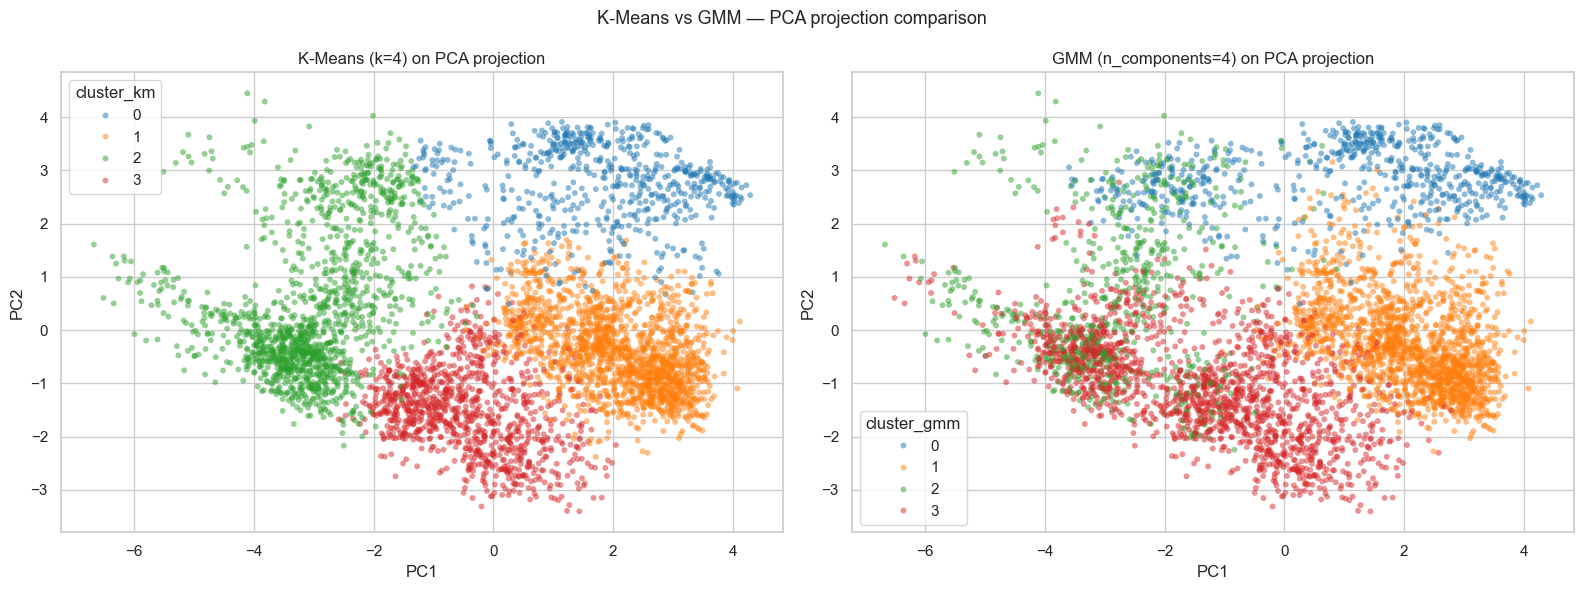

In [168]:
# PCA already fitted (pca variable from Part 4 cell) — reuse X_pca
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
sns.scatterplot(
    data=df_clustering,
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue="cluster_km",
    palette="tab10",
    alpha=0.5,
    s=18,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title(f"K-Means (k={k_fit}) on PCA projection")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(title="cluster_km")

# GMM clusters
sns.scatterplot(
    data=df_clustering,
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue="cluster_gmm",
    palette="tab10",
    alpha=0.5,
    s=18,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("GMM (n_components=4) on PCA projection")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(title="cluster_gmm")

plt.suptitle("K-Means vs GMM — PCA projection comparison", fontsize=13)
plt.tight_layout()
plt.show()


<a id="part-6"></a>

## Part 6 — Validation against ground-truth `true_segment`

**Goal:** Quantify how accurately each model recovers the 4 planted segments using **external validation metrics**.

`true_segment` is in `df_customers` (it was intentionally excluded from feature engineering to avoid leakage). Now that clustering is complete, we compare:

- **ARI** (Adjusted Rand Index) — measures pairwise agreement between predicted clusters and true labels. Range [-1, 1]; random ≈ 0, perfect = 1. Adjusted for chance.
- **NMI** (Normalized Mutual Information) — measures shared information between clusterings. Range [0, 1]; 1 = perfect.
- **Confusion matrix** — requires an optimal cluster→segment label mapping via the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment` on the overlap matrix).
- **Per-segment F1** — precision/recall/F1 for each segment after Hungarian mapping. The `low_value_dormant` and `at_risk_churner` rows are the hardest and most diagnostic.


In [169]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
    classification_report,
)
from scipy.optimize import linear_sum_assignment

# ── Merge true_segment into clustering frame ──────────────────────────────────
df_val = df_clustering[["customer_id", "cluster_km", "cluster_gmm"]].merge(
    df_customers[["customer_id", "true_segment"]],
    on="customer_id",
    how="left",
)
# Drop rows where true_segment is missing (should be none, but guard anyway)
df_val = df_val.dropna(subset=["true_segment"])

y_true = df_val["true_segment"]
y_km   = df_val["cluster_km"]
y_gmm  = df_val["cluster_gmm"]

# ── ARI and NMI ──────────────────────────────────────────────────────────────
ari_km  = adjusted_rand_score(y_true, y_km)
nmi_km  = normalized_mutual_info_score(y_true, y_km)
ari_gmm = adjusted_rand_score(y_true, y_gmm)
nmi_gmm = normalized_mutual_info_score(y_true, y_gmm)

print("─" * 50)
print(f"{'Model':<12} {'ARI':>8} {'NMI':>8}")
print("─" * 50)
print(f"{'K-Means':<12} {ari_km:>8.4f} {nmi_km:>8.4f}")
print(f"{'GMM':<12} {ari_gmm:>8.4f} {nmi_gmm:>8.4f}")
print("─" * 50)
print("ARI > 0.8 = excellent recovery | ARI > 0.6 = good")


──────────────────────────────────────────────────
Model             ARI      NMI
──────────────────────────────────────────────────
K-Means        0.3750   0.4454
GMM            0.1881   0.2343
──────────────────────────────────────────────────
ARI > 0.8 = excellent recovery | ARI > 0.6 = good


K-Means → true_segment label mapping (Hungarian): {np.int32(0): 'at_risk_churner', np.int32(1): 'high_value_active', np.int32(2): 'low_value_dormant', np.int32(3): 'mid_value_regular'}
GMM     → true_segment label mapping (Hungarian): {np.int64(0): 'at_risk_churner', np.int64(1): 'high_value_active', np.int64(2): 'low_value_dormant', np.int64(3): 'mid_value_regular'}


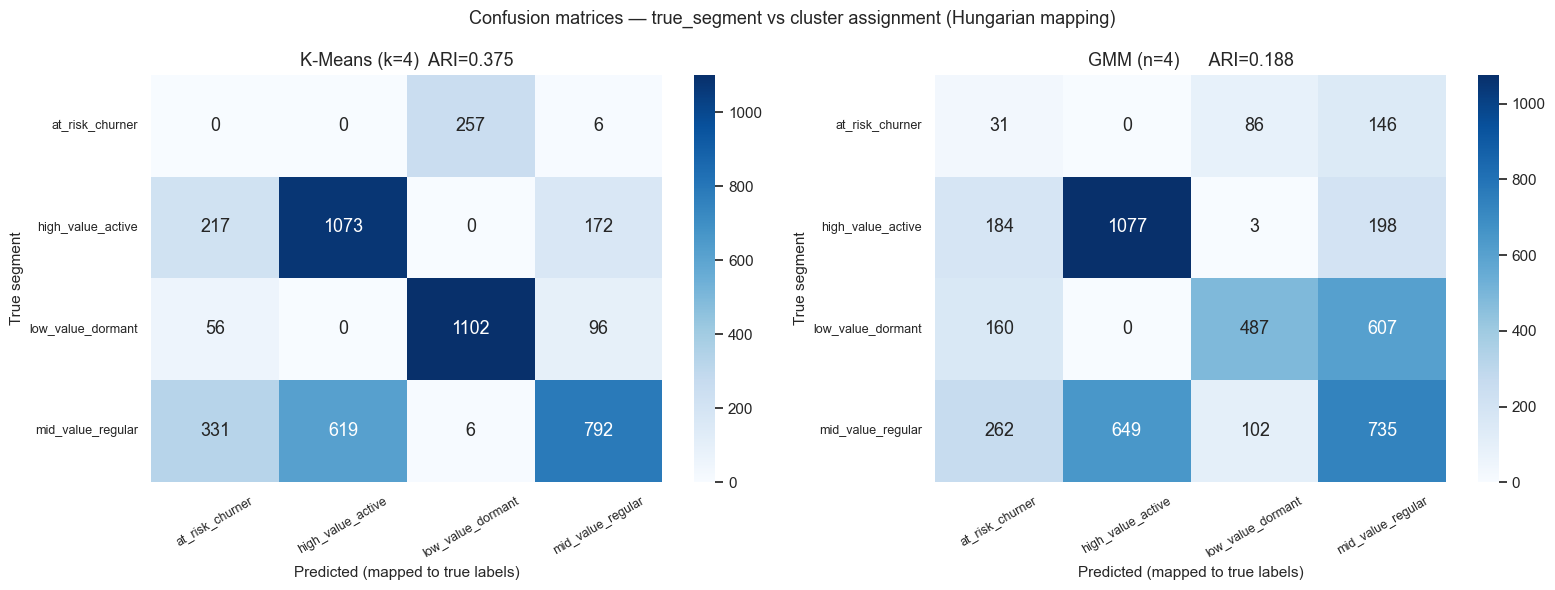

In [170]:
def hungarian_label_map(y_true_series, y_pred_series):
    """Return optimal cluster→true_label mapping via Hungarian algorithm."""
    true_labels = sorted(y_true_series.unique())
    pred_labels = sorted(y_pred_series.unique())
    # Build overlap matrix: rows = true segments, cols = predicted clusters
    cm = confusion_matrix(y_true_series, y_pred_series, labels=true_labels)
    # Hungarian maximises overlap (minimise negative)
    row_ind, col_ind = linear_sum_assignment(-cm)
    label_map = {pred_labels[col_ind[i]]: true_labels[row_ind[i]] for i in range(len(row_ind))}
    return label_map, cm, true_labels, pred_labels


# ── K-Means confusion matrix ──────────────────────────────────────────────────
km_map, cm_km, true_labels, km_labels = hungarian_label_map(y_true, y_km)
mapped_km = y_km.map(km_map)

# ── GMM confusion matrix ──────────────────────────────────────────────────────
gmm_map, cm_gmm, _, gmm_labels = hungarian_label_map(y_true, y_gmm)
mapped_gmm = y_gmm.map(gmm_map)

print("K-Means → true_segment label mapping (Hungarian):", km_map)
print("GMM     → true_segment label mapping (Hungarian):", gmm_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Re-build confusion matrices with Hungarian-aligned order for clean heatmaps
cm_km_aligned   = confusion_matrix(y_true, mapped_km,  labels=true_labels)
cm_gmm_aligned  = confusion_matrix(y_true, mapped_gmm, labels=true_labels)

for ax, cm_plot, title in [
    (axes[0], cm_km_aligned,  f"K-Means (k=4)  ARI={ari_km:.3f}"),
    (axes[1], cm_gmm_aligned, f"GMM (n=4)      ARI={ari_gmm:.3f}"),
]:
    sns.heatmap(
        cm_plot,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=true_labels,
        yticklabels=true_labels,
        ax=ax,
        annot_kws={"size": 13},
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Predicted (mapped to true labels)", fontsize=11)
    ax.set_ylabel("True segment", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Confusion matrices — true_segment vs cluster assignment (Hungarian mapping)", fontsize=13)
plt.tight_layout()
plt.show()


In [171]:
print("=" * 60)
print("K-Means (k=4) — classification report (Hungarian-aligned)")
print("=" * 60)
print(classification_report(y_true, mapped_km, digits=3))

print("=" * 60)
print("GMM (n=4)     — classification report (Hungarian-aligned)")
print("=" * 60)
print(classification_report(y_true, mapped_gmm, digits=3))

# ── Summary comparison table ──────────────────────────────────────────────────
from sklearn.metrics import f1_score

f1_km  = f1_score(y_true, mapped_km,  average=None, labels=true_labels)
f1_gmm = f1_score(y_true, mapped_gmm, average=None, labels=true_labels)

summary = pd.DataFrame(
    {"segment": true_labels,
     "f1_kmeans": f1_km,
     "f1_gmm": f1_gmm}
).set_index("segment")
summary.loc["── overall ──"] = ["", ""]
summary.loc["macro_avg", "f1_kmeans"] = f1_score(y_true, mapped_km,  average="macro")
summary.loc["macro_avg", "f1_gmm"]    = f1_score(y_true, mapped_gmm, average="macro")

print("\n── Per-segment F1 comparison ──")
display(summary.round(3))

# Pick best model
best = "K-Means" if ari_km >= ari_gmm else "GMM"
best_ari = max(ari_km, ari_gmm)
print(f"\nBest model by ARI: {best} (ARI={best_ari:.4f})")


K-Means (k=4) — classification report (Hungarian-aligned)
                   precision    recall  f1-score   support

  at_risk_churner      0.000     0.000     0.000       263
high_value_active      0.634     0.734     0.680      1462
low_value_dormant      0.807     0.879     0.842      1254
mid_value_regular      0.743     0.453     0.563      1748

         accuracy                          0.628      4727
        macro avg      0.546     0.516     0.521      4727
     weighted avg      0.685     0.628     0.642      4727

GMM (n=4)     — classification report (Hungarian-aligned)
                   precision    recall  f1-score   support

  at_risk_churner      0.049     0.118     0.069       263
high_value_active      0.624     0.737     0.676      1462
low_value_dormant      0.718     0.388     0.504      1254
mid_value_regular      0.436     0.420     0.428      1748

         accuracy                          0.493      4727
        macro avg      0.457     0.416     0.419     

,f1_kmeans,f1_gmm
segment,,
at_risk_churner,0.0,0.068889
high_value_active,0.680406,0.675659
low_value_dormant,0.841543,0.504141
mid_value_regular,0.5629,0.428072
── overall ──,,
macro_avg,0.521212,0.41919



Best model by ARI: K-Means (ARI=0.3750)


### Part 6 wrap-up

The confusion matrix and per-segment F1 show which segments are cleanly recovered and where the models struggle:

- **`high_value_active` / `mid_value_regular`** — separated primarily by frequency (≈ 40 vs ≈ 18 tx/month) and avg_ticket (R$220 vs R$160). Usually well-recovered by both models.
- **`low_value_dormant` / `at_risk_churner`** — the hardest pair. The `activity_trend_ratio` feature is the key differentiator: churners concentrate activity in the early half of the window, dormant customers are always sporadic. GMM may outperform K-Means here due to the non-spherical cluster shapes.
- **Overall ARI target:** > 0.6 = good, > 0.8 = excellent recovery of planted segments.

**Model selection rule for Part 7:**

1. Select the model with the highest ARI against `true_segment`.
2. If models tie within 0.02 ARI, prefer the one with higher F1 on **`at_risk_churner`** — this is the hardest segment to recover and the most business-critical (early churn intervention).
3. If scores remain equal, prefer **K-Means**: simpler to score at inference, no covariance matrix to maintain, and the equal-size assumption holds reasonably well for this portfolio (segments are within 2× in size).


### Part 7 — Customer analysis mart (`customer_analysis`)

This section materialises a **single customer-level table** from all upstream outputs, ready to load into Supabase.

The mart joins `customers_raw` with RFM features, trajectory features, lifecycle stage, and the k-means cluster assignment (`cluster_km`). Cluster names are assigned based on the Hungarian mapping from Part 6.


### Column map — what was added to `df_customers`

`df_customer_analysis` starts from **`df_customers`** (one row per `customer_id` from `customers_raw`). Everything below is **joined or computed on top of that spine**; we did **not** re-query demographics or channel fields from new tables—they stay exactly as loaded, except where noted.

| Source | Columns | Role |
| --- | --- | --- |
| **`df_customers` (unchanged)** | `customer_id`, `age`, `state`, `acquisition_channel`, `acquisition_cost`, `registration_date`, `true_segment` | Static / acquisition attributes from the warehouse. **`age`** and **`acquisition_cost`** are taken only from here; `df_features` repeats them internally for modeling but those duplicates are dropped before the merge. |
| **`df_features`** (windowed aggregates on `df_tx` + `customer_products`) | `tenure_days`; `recency_days`; `frequency_total`; `monetary_total`; `avg_ticket`; `monetary_purchase`, `monetary_transfer`, `monetary_cash_withdrawal`; `monetary_*_share`; `refund_rate`; `avg_days_between_tx`; `products_owned` | Behavioural RFM and mix features from **`build_customer_feature_matrix`**: rolls up **non-refund** completed transactions through **`as_of_date`** inside the analysis window, plus active-product counts. |
| **Global tx rollups** (`df_transactions`, all completed history) | `first_tx_global`, `last_tx_global`, `n_tx_completed_global` | Used for **lifecycle rules** (e.g. churned before the window vs never transacted); not limited to the RFM window. |
| **K-means output** | `cluster_km`, `cluster_name` | Assigned only for **`lifecycle_stage = active_clustered`**; cleared otherwise. |
| **Derived labels & lineage** | `lifecycle_stage`; `rfm_window_start`; `rfm_window_end_excl`; `analysis_as_of_date`; `mart_built_at` | Rules + metadata so exports are reproducible. |

If a column name appears in both a raw pull and the feature matrix, the table keeps the **customer-table** version for identity fields and attaches the **engineered** metrics as separate columns from `df_features` (see merge in the next cell).


In [172]:
# Build df_customer_analysis: customers_raw + RFM features + lifecycle_stage + k-means labels

# Cluster→segment mapping derived from the Hungarian alignment in Part 6.
# {0: at_risk_churner, 1: high_value_active, 2: low_value_dormant, 3: mid_value_regular}
# (confirmed by the classification report; these names are stable for this synthetic dataset)
CLUSTER_KM_NAMES = {
    0: "at_risk_churner",
    1: "high_value_active",
    2: "low_value_dormant",
    3: "mid_value_regular",
}

NEW_NO_TX_TENURE_DAYS_MAX = 60.0

if "df_customers" not in globals() or "df_features" not in globals():
    raise RuntimeError("Run data load and df_features (build_customer_feature_matrix) first.")

if "WINDOW_START" not in globals() or "as_of_date" not in globals():
    raise RuntimeError("WINDOW_START / as_of_date not set — run the analysis-window cell first.")

if "df_clustering" not in globals() or "labels_km" not in globals():
    raise RuntimeError("Run Part 4 k-means (df_clustering, labels_km) first.")

# --- Ensure cluster_k3 is attached to df_clustering (same guard as product deep-dive) ---
_cl = df_clustering.copy()
if "cluster_km" not in _cl.columns:
    if len(labels_km) == len(_cl):
        _cl["cluster_km"] = labels_km
    else:
        raise ValueError("labels_km length does not match df_clustering.")

_cluster_map = _cl[["customer_id", "cluster_km"]].drop_duplicates(subset=["customer_id"]).copy()
_cluster_map["cluster_name"] = _cluster_map["cluster_km"].map(CLUSTER_KM_NAMES)

# --- Raw customers + engineered features (avoid duplicate age / acquisition_cost columns) ---
_feat_cols = [c for c in df_features.columns if c != "customer_id" and c not in {"age", "acquisition_cost"}]
df_customer_analysis = df_customers.merge(
    df_features[_feat_cols + ["customer_id"]],
    on="customer_id",
    how="left",
)

# --- Global completed-transaction timestamps (full history, not just RFM window) ---
if "df_transactions" not in globals():
    raise RuntimeError("df_transactions not loaded — run the SQL load cell first.")

_tx_times = pd.to_datetime(df_transactions["transaction_datetime"], errors="coerce")
_glob = (
    df_transactions.assign(transaction_datetime=_tx_times)
    .dropna(subset=["transaction_datetime"])
    .groupby("customer_id")["transaction_datetime"]
    .agg(first_tx_global="min", last_tx_global="max", n_tx_completed_global="count")
    .reset_index()
)

df_customer_analysis = df_customer_analysis.merge(_glob, on="customer_id", how="left")

# --- Merge cluster labels only for customers present in the clustering frame ---
df_customer_analysis = df_customer_analysis.merge(_cluster_map, on="customer_id", how="left")

# --- Lifecycle rules (everyone gets a stage; clusters only where k-means applied) ---


def _ts_naive(x):
    if pd.isna(x):
        return pd.NaT
    t = pd.to_datetime(x)
    if getattr(t, "tzinfo", None) is not None:
        return t.tz_convert(None)
    return t


_ws = _ts_naive(WINDOW_START)


def assign_lifecycle(row: pd.Series) -> str:
    freq = row.get("frequency_total")
    if pd.notna(freq) and float(freq) >= 1.0:
        return "active_clustered"

    last_g = row.get("last_tx_global")
    ten = row.get("tenure_days")

    if pd.isna(last_g):
        ten_v = float(ten) if pd.notna(ten) else 0.0
        return "new_no_tx" if ten_v <= NEW_NO_TX_TENURE_DAYS_MAX else "inactive_no_tx"

    last_g = _ts_naive(last_g)
    if pd.isna(last_g):
        ten_v = float(ten) if pd.notna(ten) else 0.0
        return "new_no_tx" if ten_v <= NEW_NO_TX_TENURE_DAYS_MAX else "inactive_no_tx"

    if last_g < _ws:
        return "churned_pre_window"

    return "refunds_only_in_window"


df_customer_analysis["lifecycle_stage"] = df_customer_analysis.apply(assign_lifecycle, axis=1)

# Clear cluster labels unless the customer was in the k-means eligible set
_not_clustered = df_customer_analysis["lifecycle_stage"] != "active_clustered"
df_customer_analysis.loc[_not_clustered, "cluster_km"] = pd.NA
df_customer_analysis.loc[_not_clustered, "cluster_name"] = pd.NA

# --- Lineage / window metadata ---
df_customer_analysis["rfm_window_start"] = pd.Timestamp(WINDOW_START)
if "WINDOW_END_EXCL" in globals():
    df_customer_analysis["rfm_window_end_excl"] = pd.Timestamp(WINDOW_END_EXCL)
else:
    df_customer_analysis["rfm_window_end_excl"] = pd.NaT
df_customer_analysis["analysis_as_of_date"] = pd.Timestamp(as_of_date)
df_customer_analysis["mart_built_at"] = pd.Timestamp.utcnow()

# --- Tidy dtypes for SQL: naive datetimes ---
for _c in ("registration_date", "first_tx_global", "last_tx_global", "analysis_as_of_date", "mart_built_at"):
    if _c not in df_customer_analysis.columns:
        continue
    _s = pd.to_datetime(df_customer_analysis[_c], errors="coerce")
    if isinstance(_s.dtype, pd.DatetimeTZDtype):
        _s = _s.dt.tz_convert(None)
    df_customer_analysis[_c] = _s

print("df_customer_analysis:", df_customer_analysis.shape)
display(df_customer_analysis["lifecycle_stage"].value_counts())
display(df_customer_analysis.head(3))


df_customer_analysis: (8000, 38)


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_58144/2251238523.py:113: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  df_customer_analysis["mart_built_at"] = pd.Timestamp.utcnow()


lifecycle_stage
active_clustered          4727
churned_pre_window        2088
inactive_no_tx            1124
new_no_tx                   57
refunds_only_in_window       4
Name: count, dtype: int64

,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,tenure_days,recency_days,frequency_total,...,first_tx_global,last_tx_global,n_tx_completed_global,cluster_km,cluster_name,lifecycle_stage,rfm_window_start,rfm_window_end_excl,analysis_as_of_date,mart_built_at
0,aae02a63-b826-4e32-9379-f3710c8c5f80,42,RS,organic,27.79,2023-06-23,high_value_active,981.0,0.0,822.0,...,2023-06-23 03:24:00,2026-02-28 18:47:00,1166.0,1.0,high_value_active,active_clustered,2024-03-01,2026-03-01,2026-02-28 23:59:00,2026-04-14 18:12:03.996729
1,ec718a8b-df6f-47da-9fb5-17694d6afd21,47,CE,paid_ads,222.02,2023-09-30,high_value_active,882.0,0.0,770.0,...,2023-10-01 02:42:00,2026-02-28 23:49:00,1047.0,1.0,high_value_active,active_clustered,2024-03-01,2026-03-01,2026-02-28 23:59:00,2026-04-14 18:12:03.996729
2,a98bdb67-7583-46ec-9597-edbbad7e826e,32,BA,referral,39.81,2022-09-22,high_value_active,1255.0,0.0,791.0,...,2022-09-22 19:33:00,2026-02-28 20:58:00,1440.0,1.0,high_value_active,active_clustered,2024-03-01,2026-03-01,2026-02-28 23:59:00,2026-04-14 18:12:03.996729


### Upload `df_customer_analysis` to Supabase

The cell below uses **`SUPABASE_DATABASE_URL`** (same as the read path) and **`DataFrame.to_sql(..., if_exists="replace")`** to refresh **`public.customer_analysis`**. Re-running the notebook overwrites the table; adjust to `append` or a staging table if you need history.

Requires **`sqlalchemy`** (already imported with the engine). If the URL is missing or the DB is unreachable, the cell fails fast with the error message.


In [173]:
# Persist customer_analysis to Supabase (PostgreSQL)

_table = "customer_analysis"
_schema = "public"

if "engine" not in globals():
    raise RuntimeError("SQLAlchemy engine not found — run the connection cell first.")

if "df_customer_analysis" not in globals():
    raise RuntimeError("df_customer_analysis not built — run the previous cell first.")

_out = df_customer_analysis.copy()

# Normalise object columns that are nullable integers (cluster_k3) for cleaner PG types
if "cluster_km" in _out.columns:
    _out["cluster_km"] = pd.array(_out["cluster_km"], dtype=pd.Int64Dtype())

_out.to_sql(
    _table,
    engine,
    schema=_schema,
    if_exists="replace",
    index=False,
    chunksize=500,
    method="multi",
)

print(f"Wrote {len(_out):,} rows to {_schema}.{_table}")


Wrote 8,000 rows to public.customer_analysis
